In [1]:
!pip install scikit-image
!pip install optuna
!pip install -U torch-geometric[full]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 69.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 53.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.3/740.3 kB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 MB 42.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:01m00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:000:00:0

# **CREATION OF GRAPH DATASET**

In [ ]:
import os
import cv2
from skimage import segmentation, measure, feature
import torch
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import skew
import networkx as nx
from torch_geometric.data import Data

class ImageToGraphConverter:
    """Convertit les images en graphes basés sur les régions segmentées"""

    def __init__(self, num_segments=100, compactness=10):
        self.num_segments = num_segments
        self.compactness = compactness

    def extract_features_from_region(self, image, region_mask):
        """Extrait les caractéristiques d'une région"""
        region_pixels = image[region_mask]

        if len(region_pixels) == 0:  # Vérifier si la région est vide
            return np.zeros(20)  # Retourner un vecteur de zéros si vide

        # Caractéristiques statistiques
        mean_intensity = np.mean(region_pixels)
        std_intensity = np.std(region_pixels)
        min_intensity = np.min(region_pixels)
        max_intensity = np.max(region_pixels)

        # Statistiques avancées
        range_intensity = max_intensity - min_intensity
        cv_intensity = std_intensity / (mean_intensity + 1e-10)  # Coefficient de variation

        # Caractéristiques géométriques
        props = measure.regionprops(region_mask.astype(int))[0]
        area = props.area
        perimeter = props.perimeter
        eccentricity = props.eccentricity
        solidity = props.solidity

        # Entropie
        hist, _ = np.histogram(region_pixels, bins=256, density=True)
        hist = hist[hist > 0]  # Éviter log(0)
        entropy = -np.sum(hist * np.log2(hist)) if len(hist) > 0 else 0

        # Caractéristiques de texture (LBP)
        try:
            # Convertir l'image en uint8 pour LBP
            image_uint8 = (image * 255).astype(np.uint8)
            lbp = feature.local_binary_pattern(
                image_uint8, 8, 1, method='uniform'
            )
            lbp_hist, _ = np.histogram(lbp[region_mask], bins=10, density=True)
        except Exception as e:
            print(f"Erreur LBP: {e}")
            lbp_hist = np.zeros(10)

        features = np.array([
            mean_intensity, std_intensity, min_intensity, max_intensity,
            area, perimeter, cv_intensity,
            entropy
        ] + lbp_hist.tolist())

        return features

    def build_graph_from_image(self, image_path, label):
        """Convertit une image en graphe"""
        # Charger et préprocesser l'image
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Impossible de charger l'image: {image_path}")

        image = cv2.resize(image, (224, 224))

        # Normalisation : mettre à l'échelle dans [0, 1]
        img_min, img_max = image.min(), image.max()
        if img_max > img_min:
            image_normalized = (image - img_min) / (img_max - img_min)
        else:
            image_normalized = image / 255.0

        # Segmentation SLIC
        segments = segmentation.slic(
            image_normalized, 
            n_segments=self.num_segments,
            compactness=self.compactness, 
            start_label=1,
            channel_axis=None
        )

        # Extraire les caractéristiques pour chaque segment
        node_features = []
        centroids = []

        for region_id in np.unique(segments):
            if region_id == 0:  # Ignorer le background
                continue

            region_mask = (segments == region_id)

            # Extraire les caractéristiques
            features = self.extract_features_from_region(image_normalized, region_mask)
            node_features.append(features)

            # Calculer le centroïde
            try:
                props = measure.regionprops(region_mask.astype(int))[0]
                centroids.append([props.centroid[0], props.centroid[1]])
            except:
                continue  # Ignorer les régions invalides

        if not node_features:  # Vérifier si des nœuds ont été créés
            raise ValueError(f"Aucun nœud valide créé pour l'image: {image_path}")

        node_features = np.array(node_features)
        centroids = np.array(centroids)

        # Construire les arêtes basées sur la distance
        if len(centroids) > 1:
            distances = squareform(pdist(centroids))
            k = min(5, len(centroids) - 1)
            edges = []

            for i in range(len(centroids)):
                nearest_indices = np.argsort(distances[i])[1:k+1]
                for j in nearest_indices:
                    edges.append([i, j])
                    edges.append([j, i])  # Graphe non dirigé

            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.tensor([[0], [0]], dtype=torch.long)

        # Créer le graphe PyTorch Geometric
        x = torch.tensor(node_features, dtype=torch.float)
        y = torch.tensor([label], dtype=torch.long)
        graph_data = Data(x=x, edge_index=edge_index, y=y)

        return graph_data, segments

class BrainTumorGraphDataset:
    """Dataset pour les graphes de tumeurs cérébrales"""

    def __init__(self, data_dir, transform=None, max_samples_per_class=None):
        self.data_dir = data_dir
        self.transform = transform
        self.max_samples_per_class = max_samples_per_class

        # Classes et leurs labels
        self.classes = ['glioma', 'meningioma', 'pituitary', 'notumor']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # Collecter tous les chemins d'images
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(data_dir, class_name)
            if os.path.exists(class_dir):
                class_samples = []
                for img_name in os.listdir(class_dir):
                    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                        img_path = os.path.join(class_dir, img_name)
                        class_samples.append((img_path, self.class_to_idx[class_name]))

                # Limiter le nombre d'échantillons par classe
                if self.max_samples_per_class is not None:
                    class_samples = class_samples[:self.max_samples_per_class]
                    print(f"Classe {class_name}: {len(class_samples)} échantillons (limité)")
                else:
                    print(f"Classe {class_name}: {len(class_samples)} échantillons")

                self.samples.extend(class_samples)

    def __len__(self):
        return len(self.samples)

In [ ]:
# Paramètres
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset/Training"
TEST_DIR = "/kaggle/input/brain-tumor-mri-dataset/Testing"
MAX_SAMPLES_PER_CLASS = 5  # Limiter à 1000 images par classe
BATCH_SIZE = 32

# Créer les datasets
print("Chargement du dataset...")
dataset = BrainTumorGraphDataset(DATA_DIR, max_samples_per_class=MAX_SAMPLES_PER_CLASS)
test_dataset = BrainTumorGraphDataset(TEST_DIR, max_samples_per_class=MAX_SAMPLES_PER_CLASS)
converter = ImageToGraphConverter(num_segments=100, compactness=10)

# Convertir les images en graphes
graph_dataset_train = [converter.build_graph_from_image(img, lbl) for img, lbl in dataset.samples]
graph_dataset_test = [converter.build_graph_from_image(img, lbl) for img, lbl in test_dataset.samples]

print(f"Dataset d'entraînement : {len(graph_dataset_train)} graphes")
print(f"Dataset de test : {len(graph_dataset_test)} graphes")

In [ ]:
print(len(graph_dataset_train))

Normalize

In [ ]:
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
from torchvision import datasets
import random

import os
import cv2
from skimage import segmentation, measure, feature
import torch
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import skew, kurtosis
import networkx as nx
from torch_geometric.data import Data

class ImageToGraphConverter:
    """Convertit les images en graphes basés sur les régions segmentées"""

    def __init__(self, num_segments=100, compactness=10):
        self.num_segments = num_segments
        self.compactness = compactness

    def extract_features_from_region(self, image, region_mask):
        """Extrait les caractéristiques d'une région"""
        region_pixels = image[region_mask]

        # Caractéristiques statistiques
        mean_intensity = np.mean(region_pixels)
        std_intensity = np.std(region_pixels)
        min_intensity = np.min(region_pixels)
        max_intensity = np.max(region_pixels)

        # Statistiques avancées
        range_intensity = max_intensity - min_intensity
        cv_intensity = std_intensity / (mean_intensity + 1e-10)  # Coefficient de variation
        
        # Caractéristiques géométriques
        props = measure.regionprops(region_mask.astype(int))[0]
        area = props.area
        perimeter = props.perimeter
        eccentricity = props.eccentricity
        solidity = props.solidity

        # Entropie
        hist, _ = np.histogram(region_pixels, bins=256, density=True)
        hist = hist[hist > 0]  # Éviter log(0)
        entropy = -np.sum(hist * np.log2(hist))

        # Caractéristiques de texture (LBP)
        try:
            lbp = feature.local_binary_pattern(
                cv2.cvtColor(image, cv2.COLOR_BGR2GRAY), 8, 1, method='uniform'
            )
            lbp_hist, _ = np.histogram(lbp[region_mask], bins=10, density=True)
        except:
            lbp_hist = np.zeros(10)

        features = np.array([
            mean_intensity, std_intensity, min_intensity, max_intensity,
            area, perimeter, eccentricity, solidity, range_intensity, cv_intensity
        ] + lbp_hist.tolist())

        return features

    def build_graph_from_image(self, image_path, label):
        """Convertit une image en graphe"""
        # Charger et préprocesser l'image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Impossible de charger l'image: {image_path}")

        #image = cv2.resize(image, (224, 224))
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Segmentation SLIC
        segments = segmentation.slic(
            image, n_segments=self.num_segments,
            compactness=self.compactness, start_label=1
        )

        # Extraire les caractéristiques pour chaque segment
        node_features = []
        centroids = []

        for region_id in np.unique(segments):
            if region_id == 0:  # Ignorer le background
                continue

            region_mask = (segments == region_id)

            # Extraire les caractéristiques
            features = self.extract_features_from_region(image, region_mask)
            node_features.append(features)

            # Calculer le centroïde
            props = measure.regionprops(region_mask.astype(int))[0]
            centroids.append([props.centroid[0], props.centroid[1]])

        node_features = np.array(node_features)
        centroids = np.array(centroids)

        # Construire les arêtes basées sur la distance
        if len(centroids) > 1:
            distances = squareform(pdist(centroids))
            # Connecter chaque nœud à ses k plus proches voisins
            k = min(5, len(centroids) - 1)
            edges = []

            for i in range(len(centroids)):
                # Trouver les k plus proches voisins
                nearest_indices = np.argsort(distances[i])[1:k+1]
                for j in nearest_indices:
                    edges.append([i, j])
                    edges.append([j, i])  # Graphe non dirigé

            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        else:
            # Si un seul nœud, créer un graphe avec auto-boucle
            edge_index = torch.tensor([[0], [0]], dtype=torch.long)

        # Créer le graphe PyTorch Geometric
        x = torch.tensor(node_features, dtype=torch.float)
        y = torch.tensor([label], dtype=torch.long)
        graph_data = Data(x=x, edge_index=edge_index, y=y, dtype=torch.long)

        return graph_data


# 1. TRANSFORMATIONS D'ENTRAÎNEMENT (avec augmentation)
transform = transforms.Compose([
     transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])
converter = ImageToGraphConverter()
DATA_DIR = "/kaggle/input/brain-tumor-mri-dataset/Training" 
TEST_DIR = "/kaggle/input/brain-tumor-mri-dataset/Testing" 
train_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=transform)
graph_dataset_train = [g for g in (converter.build_graph_from_image(img, lbl) for img, lbl in train_dataset.samples) if g is not None]
graph_dataset_test =  [g for g in (converter.build_graph_from_image(img, lbl) for img, lbl in test_dataset.samples) if g is not None]

# **SAVE**

In [ ]:
import os
import torch

# Créez un répertoire pour sauvegarder les graphes si nécessaire
# Vous pouvez choisir un nom de répertoire différent si vous le souhaitez
processed_data_dir = '/kaggle/working/processed_graphs' # Recommandé pour sauvegarder sur Drive
os.makedirs(processed_data_dir, exist_ok=True)

# Sauvegardez les graphes d'entraînement
train_graphs_path = os.path.join(processed_data_dir, 'data_graphs_all.pt')
torch.save(graph_dataset_train, train_graphs_path)
print(f"Graphes d'entraînement sauvegardés dans : {train_graphs_path}")

# Sauvegardez les graphes de test
test_graphs_path = os.path.join(processed_data_dir, 'data_graphs_test_all.pt')
torch.save(graph_dataset_test, test_graphs_path)
print(f"Graphes d'entraînement sauvegardés dans : {test_graphs_path}")


# **LOAD DATA**

In [2]:
import torch
from torch_geometric.data import Data # Import Data class
from torch_geometric.loader import DataLoader

# Load the graphs, allowing the loading of non-tensor objects
graph_dataset_train = torch.load('/kaggle/input/graph-data/data_graphs_all.pt', weights_only=False)
graph_dataset_test = torch.load('/kaggle/input/graph-data/data_graphs_test_all.pt', weights_only=False)

# **MODEL**

# **GCN** and **GRU**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from typing import Optional, Union, Dict

def visualize_confidence_distribution(
    confidences: Union[np.ndarray, torch.Tensor],
    predictions: Union[np.ndarray, torch.Tensor],
    y_true: Union[np.ndarray, torch.Tensor],
    save_path: Optional[str] = None,
    class_names: Optional[Dict[int, str]] = None
) -> plt.Figure:
    """
    Visualize the distribution of confidence scores with multiple perspectives.
    
    Args:
        confidences: Confidence scores for predictions (shape: [n_samples])
        predictions: Model predictions (shape: [n_samples]) OR binary correctness array
        y_true: True labels (shape: [n_samples])
        save_path: Optional path to save the figure
        class_names: Optional dictionary mapping class indices to names
        
    Returns:
        matplotlib Figure object
    """
    # Convert tensors to numpy arrays and flatten
    if torch.is_tensor(confidences):
        confidences = confidences.cpu().numpy()
    if torch.is_tensor(correctness):
        correctness = correctness.cpu().numpy()
    if torch.is_tensor(y_true):
        y_true = y_true.cpu().numpy()
    
    # Ensure arrays are flat and convert lists/nested arrays properly
    confidences = np.asarray(confidences).flatten()
    predictions = np.asarray(predictions).flatten()
    y_true = np.asarray(y_true).flatten()
    
    # Verify all arrays have the same length
    if not (len(confidences) == len(predictions) == len(y_true)):
        raise ValueError(f"Array length mismatch: confidences={len(confidences)}, "
                        f"predictions={len(predictions)}, y_true={len(y_true)}")
    
    # Check if predictions is actually a correctness array (binary 0/1)
    # or actual class predictions
    if set(np.unique(predictions)) <= {0, 1}:
        # It's a correctness array
        correctness = predictions.astype(bool)
    else:
        # It's actual predictions, calculate correctness
        correctness = (predictions == y_true)
    
    # Default class names
    if class_names is None:
        class_names = {
            0: "Glioma",
            1: "Meningioma",
            2: "Pituitary",
            3: "No Tumor"
        }
    
    # Create figure with subplots
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # Main title
    fig.suptitle('Confidence Score Analysis by Class', fontsize=16, fontweight='bold', y=0.995)
    
    # ========== Row 1: Overall Statistics ==========
    # 1. Overall confidence distribution
    ax1 = fig.add_subplot(gs[0, 0])
    n, bins, patches = ax1.hist(confidences, bins=30, alpha=0.7, 
                                color='steelblue', edgecolor='black')
    mean_conf = confidences.mean()
    median_conf = np.median(confidences)
    ax1.axvline(mean_conf, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_conf:.3f}')
    ax1.axvline(median_conf, color='orange', linestyle='--', linewidth=2, 
               label=f'Median: {median_conf:.3f}')
    ax1.set_xlabel('Confidence Score', fontsize=10)
    ax1.set_ylabel('Frequency', fontsize=10)
    ax1.set_title('Overall Confidence Distribution', fontsize=11, fontweight='bold')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # 2. Correct vs Incorrect predictions
    ax2 = fig.add_subplot(gs[0, 1])
    correct_conf = confidences[correctness]
    incorrect_conf = confidences[~correctness]
    
    ax2.hist([correct_conf, incorrect_conf], bins=20, alpha=0.7,
            label=[f'Correct (μ={correct_conf.mean():.3f}, n={len(correct_conf)})', 
                   f'Incorrect (μ={incorrect_conf.mean():.3f}, n={len(incorrect_conf)})'],
            color=['green', 'red'], edgecolor='black')
    ax2.set_xlabel('Confidence Score', fontsize=10)
    ax2.set_ylabel('Frequency', fontsize=10)
    ax2.set_title('Confidence: Correct vs Incorrect', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # 3. Box plot by class
    ax3 = fig.add_subplot(gs[0, 2])
    unique_classes = np.sort(np.unique(y_true))
    confidence_by_class = [confidences[y_true == c] for c in unique_classes]
    class_labels = [class_names.get(int(c), f"Class {c}") for c in unique_classes]
    
    bp = ax3.boxplot(confidence_by_class, labels=class_labels, patch_artist=True,
                    showmeans=True, meanprops=dict(marker='D', markerfacecolor='red', 
                                                    markersize=6))
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(bp['boxes'])))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax3.set_xlabel('True Class', fontsize=10)
    ax3.set_ylabel('Confidence Score', fontsize=10)
    ax3.set_title('Confidence Distribution by Class', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # ========== Row 2: Per-Class Analysis ==========
    unique_classes = np.sort(np.unique(y_true))
    n_classes = len(unique_classes)
    
    for idx, class_id in enumerate(unique_classes):
        ax = fig.add_subplot(gs[1, idx])
        
        # Filter data for this class
        class_mask = (y_true == class_id)
        class_confidences = confidences[class_mask]
        class_correctness = correctness[class_mask]
        
        # Separate correct and incorrect for this class
        correct_mask = class_correctness
        incorrect_mask = ~class_correctness
        
        correct_conf_class = class_confidences[correct_mask]
        incorrect_conf_class = class_confidences[incorrect_mask]
        
        # Plot histogram
        if len(incorrect_conf_class) > 0:
            ax.hist([correct_conf_class, incorrect_conf_class], 
                   bins=15, alpha=0.7,
                   label=[f'Correct ({len(correct_conf_class)})', 
                          f'Incorrect ({len(incorrect_conf_class)})'],
                   color=['green', 'red'], edgecolor='black')
        else:
            ax.hist(correct_conf_class, bins=15, alpha=0.7,
                   label=f'Correct ({len(correct_conf_class)})',
                   color='green', edgecolor='black')
        
        # Calculate statistics
        accuracy = correct_mask.mean() * 100
        mean_conf = class_confidences.mean()
        
        class_name = class_names.get(int(class_id), f"Class {class_id}")
        ax.set_title(f'{class_name}\nAcc: {accuracy:.1f}% | μ: {mean_conf:.3f}', 
                    fontsize=10, fontweight='bold')
        ax.set_xlabel('Confidence', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, alpha=0.3)
        ax.set_xlim([0, 1])
    
    # ========== Row 3: Accuracy per Class and Calibration ==========
    # 1. Accuracy and sample count per class
    ax_acc = fig.add_subplot(gs[2, 0])
    class_accuracies = []
    class_counts = []
    
    for class_id in unique_classes:
        class_mask = (y_true == class_id)
        class_acc = correctness[class_mask].mean() * 100
        class_count = class_mask.sum()
        class_accuracies.append(class_acc)
        class_counts.append(class_count)
    
    x_pos = np.arange(len(class_labels))
    bars = ax_acc.bar(x_pos, class_accuracies, alpha=0.7, 
                      color=colors, edgecolor='black', linewidth=1.5)
    
    # Add sample counts on bars
    for i, (acc, count) in enumerate(zip(class_accuracies, class_counts)):
        ax_acc.text(i, acc + 2, f'n={count}', 
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax_acc.set_xlabel('Class', fontsize=10)
    ax_acc.set_ylabel('Accuracy (%)', fontsize=10)
    ax_acc.set_title('Accuracy per Class', fontsize=11, fontweight='bold')
    ax_acc.set_xticks(x_pos)
    ax_acc.set_xticklabels(class_labels, rotation=15, ha='right')
    ax_acc.set_ylim([0, 105])
    ax_acc.grid(True, alpha=0.3, axis='y')
    ax_acc.axhline(y=correctness.mean()*100, color='red', linestyle='--', 
                   linewidth=2, label=f'Overall: {correctness.mean()*100:.1f}%')
    ax_acc.legend(fontsize=9)
    
    # 2. Mean confidence per class
    ax_conf = fig.add_subplot(gs[2, 1])
    mean_confidences = [confidences[y_true == c].mean() for c in unique_classes]
    
    bars = ax_conf.bar(x_pos, mean_confidences, alpha=0.7,
                      color=colors, edgecolor='black', linewidth=1.5)
    
    ax_conf.set_xlabel('Class', fontsize=10)
    ax_conf.set_ylabel('Mean Confidence', fontsize=10)
    ax_conf.set_title('Mean Confidence per Class', fontsize=11, fontweight='bold')
    ax_conf.set_xticks(x_pos)
    ax_conf.set_xticklabels(class_labels, rotation=15, ha='right')
    ax_conf.set_ylim([0, 1])
    ax_conf.grid(True, alpha=0.3, axis='y')
    ax_conf.axhline(y=confidences.mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Overall: {confidences.mean():.3f}')
    ax_conf.legend(fontsize=9)
    
    # 3. Calibration curve
    ax_cal = fig.add_subplot(gs[2, 2])
    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_indices = np.digitize(confidences, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)
    
    bin_accuracies = []
    bin_counts = []
    for i in range(n_bins):
        mask = bin_indices == i
        if mask.sum() > 0:
            bin_accuracies.append(correctness[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_accuracies.append(np.nan)
            bin_counts.append(0)
    
    # Plot with point sizes proportional to number of samples
    valid_mask = ~np.isnan(bin_accuracies)
    sizes = np.array(bin_counts)[valid_mask] / len(confidences) * 1000
    
    ax_cal.scatter(bin_centers[valid_mask], np.array(bin_accuracies)[valid_mask],
                  s=sizes, alpha=0.7, color='coral', edgecolors='black', 
                  linewidths=1.5, label='Confidence bins')
    ax_cal.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=2, 
               label='Perfect calibration')
    
    # Add ECE (Expected Calibration Error)
    bin_weights = np.array(bin_counts) / len(confidences)
    ece = np.sum(bin_weights * np.abs(bin_centers - np.nan_to_num(bin_accuracies)))
    
    ax_cal.set_xlabel('Mean Confidence', fontsize=10)
    ax_cal.set_ylabel('Accuracy', fontsize=10)
    ax_cal.set_title(f'Calibration Curve (ECE: {ece:.3f})', 
                    fontsize=11, fontweight='bold')
    ax_cal.legend(loc='upper left', fontsize=9)
    ax_cal.grid(True, alpha=0.3)
    ax_cal.set_xlim([0, 1])
    ax_cal.set_ylim([0, 1])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    return fig

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import torch
import torch.nn.functional as F
from tqdm import tqdm

def compute_ece_and_reliability_diagram(model, test_loader, num_bins=10, save_path=None):
    """
    Version CORRIGÉE et ROBUSTE du calcul d'ECE + Reliability Diagram
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    
    all_confidences = []
    all_correctness = []  # 1 si prédiction correcte, 0 sinon
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Collecting predictions for calibration"):
            batch = batch.to(device)
            outputs, _ = model(batch)
            probs = F.softmax(outputs, dim=1)
            confidences, predictions = torch.max(probs, dim=1)
            
            targets = batch.y.view(-1)  # au cas où y ait une dimension en trop
            
            correctness = (predictions == targets).float()
            
            all_confidences.append(confidences.cpu().numpy())
            all_correctness.append(correctness.cpu().numpy())
            all_labels.append(batch.y.cpu().numpy())
    
    # Concaténation
    confidences = np.concatenate(all_confidences)
    correctness = np.concatenate(all_correctness).astype(int)
    all_labels = np.concatenate(all_labels)
    
    n_samples = len(confidences)
    print(f"Nombre total d'échantillons évalués : {n_samples}")
    
    # === Calcul manuel des bins (plus fiable que calibration_curve) ===
    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    accuracies = []
    confidences_avg = []
    bin_sizes = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Indices dans ce bin
        in_bin = (confidences >= bin_lower) & (confidences < bin_upper)
        bin_size = np.sum(in_bin)
        bin_sizes.append(bin_size)
        
        if bin_size > 0:
            accuracy_in_bin = np.mean(correctness[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            accuracies.append(accuracy_in_bin)
            confidences_avg.append(avg_confidence_in_bin)
        else:
            # ✅ Ne pas ajouter les bins vides au diagramme
            accuracies.append(np.nan)
            confidences_avg.append(np.nan)
    
    accuracies = np.array(accuracies)
    confidences_avg = np.array(confidences_avg)
    bin_sizes = np.array(bin_sizes)
    
    # === ECE (seulement sur les bins non-vides) ===
    mask_non_empty = bin_sizes > 0
    ece = np.sum(bin_sizes[mask_non_empty] / n_samples * 
                 np.abs(accuracies[mask_non_empty] - confidences_avg[mask_non_empty]))
    
    # === Brier Score ===
    brier = np.mean((confidences - correctness) ** 2)
    
    # === Accuracy globale ===
    overall_accuracy = np.mean(correctness)
    
    print(f"Expected Calibration Error (ECE, {num_bins} bins): {ece:.4f}")
    print(f"Brier Score: {brier:.4f}")
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    
    # === Reliability Diagram ===
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # ========== Graphique 1: Reliability Diagram ==========
    # Filtrer les bins non-vides pour la visualisation
    non_empty_indices = np.where(mask_non_empty)[0]
    non_empty_confidences = confidences_avg[mask_non_empty]
    non_empty_accuracies = accuracies[mask_non_empty]
    non_empty_sizes = bin_sizes[mask_non_empty]
    
    # Barres (accuracy vs confidence moyenne)
    bin_width = 1.0 / num_bins
    ax1.bar(non_empty_confidences, non_empty_accuracies, 
            width=bin_width * 0.9, alpha=0.6, 
            color='steelblue', edgecolor='black', linewidth=1.5,
            label='Outputs')
    
    # Points de calibration observés
    ax1.scatter(non_empty_confidences, non_empty_accuracies, 
                color='darkblue', s=100, zorder=5, 
                edgecolors='black', linewidth=1.5, label='Gap')
    
    # Ligne diagonale parfaite (y = x)
    ax1.plot([0, 1], [0, 1], '--', color='red', linewidth=2.5, 
             label='Perfectly calibrated')
    
    # Ajouter le nombre d'exemples par bin
    for conf, acc, size in zip(non_empty_confidences, non_empty_accuracies, non_empty_sizes):
        ax1.text(conf, acc + 0.03, f'{size}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax1.set_xlabel("Confidence", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Accuracy", fontsize=14, fontweight='bold')
    ax1.set_title(f"Reliability Diagram\n"
                  f"ECE = {ece:.4f} | Accuracy = {overall_accuracy:.4f}", 
                  fontsize=16, fontweight='bold')
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    ax1.set_aspect('equal')  # Ratio 1:1
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11, loc='upper left')
    
    # ========== Graphique 2: Distribution des échantillons ==========
    bin_centers = (bin_lowers + bin_uppers) / 2
    ax2.bar(bin_centers, bin_sizes, width=bin_width * 0.9, 
            alpha=0.7, color='coral', edgecolor='black', linewidth=1.5)
    
    # Ajouter les valeurs au-dessus des barres
    for center, size in zip(bin_centers, bin_sizes):
        if size > 0:
            ax2.text(center, size + n_samples*0.01, f'{size}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax2.set_xlabel("Confidence Bin", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Number of Samples", fontsize=14, fontweight='bold')
    ax2.set_title(f"Sample Distribution\n(Total: {n_samples} samples)", 
                  fontsize=16, fontweight='bold')
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Diagramme sauvegardé : {save_path}")

    fig2 = visualize_confidence_distribution(
        confidences, correctness, all_labels, 
        save_path='/kaggle/working/confidence_distribution.png'
    )
    
    plt.show()
    
    return ece, brier, overall_accuracy

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchmetrics.classification import CalibrationError
from tqdm import tqdm
from typing import Optional, Dict, List


def predict_with_uncertainty_vgrnn(model, data, num_samples=50):
    """
    Generate predictions with uncertainty using variational inference in VGRNN
    
    Args:
        model: ImprovedVGRNN model
        data: PyTorch Geometric data batch
        num_samples: Number of Monte Carlo samples
        
    Returns:
        mean_probs: Mean predicted probabilities [batch_size, num_classes]
        std_probs: Standard deviation of probabilities [batch_size, num_classes]
        all_probs: All sampled probabilities [num_samples, batch_size, num_classes]
        epistemic_uncertainty: Model uncertainty [batch_size]
        aleatoric_uncertainty: Data uncertainty [batch_size]
    """
    model.train()  # Keep dropout and stochastic sampling active
    device = next(model.parameters()).device
    data = data.to(device)
    
    all_logits = []
    all_klds = []
    
    with torch.no_grad():
        for _ in range(num_samples):
            # Forward pass with stochastic sampling
            logits, kld = model(data)
            all_logits.append(logits)
            all_klds.append(kld.item())
    
    # Stack all predictions
    all_logits = torch.stack(all_logits)  # [num_samples, batch_size, num_classes]
    all_probs = F.softmax(all_logits, dim=-1)
    
    # Mean probabilities (predictive distribution)
    mean_probs = all_probs.mean(dim=0)
    
    # Standard deviation of probabilities
    std_probs = all_probs.std(dim=0)
    
    # Predictive entropy (total uncertainty)
    predictive_entropy = -(mean_probs * torch.log(mean_probs + 1e-10)).sum(dim=-1)
    
    # Expected entropy (aleatoric uncertainty - data noise)
    individual_entropy = -(all_probs * torch.log(all_probs + 1e-10)).sum(dim=-1)
    expected_entropy = individual_entropy.mean(dim=0)
    
    # Mutual information (epistemic uncertainty - model uncertainty)
    mutual_information = predictive_entropy - expected_entropy
    
    return mean_probs, std_probs, all_probs, mutual_information, expected_entropy


def compute_ece_mce_vgrnn(model, test_loader, num_samples=50, n_bins=10):
    """
    Compute Expected Calibration Error (ECE) and Maximum Calibration Error (MCE)
    using TorchMetrics with variational inference
    
    Args:
        model: ImprovedVGRNN model
        test_loader: Test data loader (GeometricDataLoader)
        num_samples: Number of Monte Carlo samples for uncertainty
        n_bins: Number of bins for calibration metrics
        
    Returns:
        Dictionary with calibration metrics and additional information
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Store all predictions and targets
    all_mean_probs = []
    all_targets = []
    all_epistemic = []
    all_aleatoric = []
    all_std_probs = []
    
    print(f"Computing calibration metrics with {num_samples} MC samples...")
    
    for batch in tqdm(test_loader, desc='Processing batches'):
        batch = batch.to(device)
        
        # Get predictions with uncertainty
        mean_probs, std_probs, _, epistemic, aleatoric = predict_with_uncertainty_vgrnn(
            model, batch, num_samples=num_samples
        )
        
        all_mean_probs.append(mean_probs.cpu())
        all_targets.append(batch.y.cpu())
        all_epistemic.append(epistemic.cpu())
        all_aleatoric.append(aleatoric.cpu())
        all_std_probs.append(std_probs.cpu())
    
    # Concatenate all batches
    all_mean_probs = torch.cat(all_mean_probs, dim=0)
    all_targets = torch.cat(all_targets, dim=0).squeeze()
    all_epistemic = torch.cat(all_epistemic, dim=0)
    all_aleatoric = torch.cat(all_aleatoric, dim=0)
    all_std_probs = torch.cat(all_std_probs, dim=0)
    
    # Get number of classes
    num_classes = all_mean_probs.shape[1]
    
    print(f"\nDataset statistics:")
    print(f"  Total samples: {len(all_targets)}")
    print(f"  Number of classes: {num_classes}")
    print(f"  Mean epistemic uncertainty: {all_epistemic.mean():.4f}")
    print(f"  Mean aleatoric uncertainty: {all_aleatoric.mean():.4f}")
    
    # Initialize TorchMetrics calibration metrics
    ece_metric = CalibrationError(
        task='multiclass',
        num_classes=num_classes,
        n_bins=n_bins,
        norm='l1'  # L1 norm for ECE
    )
    
    mce_metric = CalibrationError(
        task='multiclass',
        num_classes=num_classes,
        n_bins=n_bins,
        norm='max'  # Max norm for MCE
    )
    
    # Compute calibration errors
    ece = ece_metric(all_mean_probs, all_targets)
    mce = mce_metric(all_mean_probs, all_targets)
    
    # Compute additional metrics
    predictions = torch.argmax(all_mean_probs, dim=1)
    accuracy = (predictions == all_targets).float().mean()
    
    # Confidence metrics
    confidences, _ = torch.max(all_mean_probs, dim=1)
    avg_confidence = confidences.mean()
    
    # Brier score
    targets_one_hot = F.one_hot(all_targets.long(), num_classes=num_classes).float()
    brier_score = ((all_mean_probs - targets_one_hot) ** 2).sum(dim=1).mean()
    
    # Negative Log-Likelihood
    nll = F.cross_entropy(all_mean_probs, all_targets.long())
    
    print(f"\n{'='*60}")
    print("CALIBRATION METRICS (with Variational Inference)")
    print(f"{'='*60}")
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    print(f"Maximum Calibration Error (MCE):  {mce:.4f}")
    print(f"Accuracy:                          {accuracy:.4f}")
    print(f"Average Confidence:                {avg_confidence:.4f}")
    print(f"Brier Score:                       {brier_score:.4f}")
    print(f"Negative Log-Likelihood:           {nll:.4f}")
    print(f"{'='*60}")
    
    # Get reliability diagram data
    reliability_data = get_reliability_diagram_data_multiclass(
        all_mean_probs, all_targets, n_bins
    )
    
    results = {
        'ece': ece.item(),
        'mce': mce.item(),
        'accuracy': accuracy.item(),
        'avg_confidence': avg_confidence.item(),
        'brier_score': brier_score.item(),
        'nll': nll.item(),
        'reliability_data': reliability_data,
        'predictions': predictions.numpy(),
        'targets': all_targets.numpy(),
        'probabilities': all_mean_probs.numpy(),
        'epistemic_uncertainty': all_epistemic.numpy(),
        'aleatoric_uncertainty': all_aleatoric.numpy(),
        'std_probs': all_std_probs.numpy(),
        'confidences': confidences.numpy()
    }
    
    return results


def get_reliability_diagram_data_multiclass(probs, labels, n_bins=15):
    """
    Extract data for reliability diagram (multiclass version)
    
    Args:
        probs: Predicted probabilities [N, num_classes]
        labels: True labels [N]
        n_bins: Number of bins
        
    Returns:
        Dictionary with binned statistics
    """
    confidences, predictions = torch.max(probs, dim=1)
    accuracies = predictions.eq(labels)
    
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    bin_confidences = []
    bin_accuracies = []
    bin_counts = []
    bin_gaps = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        count_in_bin = in_bin.sum().item()
        
        if count_in_bin > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean().item()
            avg_confidence_in_bin = confidences[in_bin].mean().item()
            gap = abs(avg_confidence_in_bin - accuracy_in_bin)
            
            bin_confidences.append(avg_confidence_in_bin)
            bin_accuracies.append(accuracy_in_bin)
            bin_counts.append(count_in_bin)
            bin_gaps.append(gap)
        else:
            bin_confidences.append(None)
            bin_accuracies.append(None)
            bin_counts.append(0)
            bin_gaps.append(None)
    
    return {
        'confidences': bin_confidences,
        'accuracies': bin_accuracies,
        'counts': bin_counts,
        'gaps': bin_gaps,
        'n_bins': n_bins
    }


def plot_comprehensive_calibration_analysis(results, class_names=None, save_path=None):
    """
    Create comprehensive calibration analysis plots
    
    Args:
        results: Dictionary from compute_ece_mce_vgrnn
        class_names: List of class names
        save_path: Path to save the figure
    """
    if class_names is None:
        class_names = ['glioma', 'meningioma', 'pituitary', 'notumor']
    
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    reliability_data = results['reliability_data']
    
    # 1. Reliability Diagram (main calibration plot)
    ax1 = fig.add_subplot(gs[0, :2])
    plot_reliability_diagram_advanced(ax1, reliability_data, results)
    
    # 2. Calibration Error per Bin
    ax2 = fig.add_subplot(gs[0, 2])
    plot_calibration_errors_per_bin(ax2, reliability_data)
    
    # 3. Confidence Distribution
    ax3 = fig.add_subplot(gs[1, 0])
    plot_confidence_distribution(ax3, results)
    
    # 4. Uncertainty vs Correctness
    ax4 = fig.add_subplot(gs[1, 1])
    plot_uncertainty_vs_correctness(ax4, results)
    
    # 5. Class-wise Calibration
    ax5 = fig.add_subplot(gs[1, 2])
    plot_classwise_calibration(ax5, results, class_names)
    
    # 6. Epistemic vs Aleatoric Uncertainty
    ax6 = fig.add_subplot(gs[2, 0])
    plot_epistemic_vs_aleatoric(ax6, results)
    
    # 7. Confidence vs Uncertainty
    ax7 = fig.add_subplot(gs[2, 1])
    plot_confidence_vs_uncertainty(ax7, results)
    
    # 8. Summary Statistics
    ax8 = fig.add_subplot(gs[2, 2])
    plot_summary_statistics(ax8, results)
    
    plt.suptitle('Comprehensive Calibration Analysis with Variational Inference', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nFigure saved to: {save_path}")

    plt.tight_layout()
    
    plt.show()


def plot_reliability_diagram_advanced(ax, reliability_data, results):
    """Plot advanced reliability diagram"""
    confidences = [c for c in reliability_data['confidences'] if c is not None]
    accuracies = [a for a in reliability_data['accuracies'] if a is not None]
    counts = [c for c in reliability_data['counts'] if c > 0]
    
    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect calibration', alpha=0.7)
    
    # Bar plot with width proportional to bin size
    bin_width = 1.0 / reliability_data['n_bins']
    bars = ax.bar(confidences, accuracies, width=bin_width * 0.8, 
                  alpha=0.7, edgecolor='black', linewidth=1.5,
                  color='steelblue', label='Model calibration')
    
    # Add gap indicators
    for conf, acc in zip(confidences, accuracies):
        gap_color = 'red' if acc < conf else 'green'
        ax.plot([conf, conf], [conf, acc], color=gap_color, 
               linewidth=2, alpha=0.6)
    
    # Add sample counts as text
    for conf, count in zip(confidences, counts):
        ax.text(conf, 0.05, str(count), ha='center', va='bottom',
               fontsize=8, color='darkred', fontweight='bold')
    
    ax.set_xlabel('Confidence', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title(f'Reliability Diagram\nECE: {results["ece"]:.4f} | MCE: {results["mce"]:.4f}',
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])


def plot_calibration_errors_per_bin(ax, reliability_data):
    """Plot calibration error per bin"""
    gaps = [g for g in reliability_data['gaps'] if g is not None]
    confidences = [c for c in reliability_data['confidences'] if c is not None]
    
    colors = ['green' if g < 0.1 else 'orange' if g < 0.2 else 'red' for g in gaps]
    
    ax.bar(range(len(gaps)), gaps, color=colors, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Bin Index', fontsize=11, fontweight='bold')
    ax.set_ylabel('Calibration Gap', fontsize=11, fontweight='bold')
    ax.set_title('Calibration Error per Bin', fontsize=11, fontweight='bold')
    ax.axhline(y=0.1, color='orange', linestyle='--', alpha=0.5, label='0.1 threshold')
    ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='0.2 threshold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')


def plot_confidence_distribution(ax, results):
    """Plot confidence distribution"""
    confidences = results['confidences']
    
    ax.hist(confidences, bins=30, alpha=0.7, color='steelblue', 
           edgecolor='black', density=True)
    ax.axvline(x=confidences.mean(), color='red', linestyle='--', 
              linewidth=2, label=f'Mean: {confidences.mean():.3f}')
    ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax.set_title('Confidence Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')


def plot_uncertainty_vs_correctness(ax, results):
    """Plot uncertainty vs prediction correctness"""
    total_uncertainty = results['epistemic_uncertainty'] + results['aleatoric_uncertainty']
    correct = (results['predictions'] == results['targets']).astype(float)
    
    # Scatter plot with jitter
    jitter = np.random.normal(0, 0.02, size=len(correct))
    ax.scatter(total_uncertainty, correct + jitter, alpha=0.3, s=20)
    
    # Box plots for correct/incorrect
    positions = [0, 1]
    data_to_plot = [total_uncertainty[correct == 0], total_uncertainty[correct == 1]]
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.3, 
                    patch_artist=True, vert=False)
    
    for patch, color in zip(bp['boxes'], ['lightcoral', 'lightgreen']):
        patch.set_facecolor(color)
    
    ax.set_ylabel('Correct (1) / Incorrect (0)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Total Uncertainty', fontsize=11, fontweight='bold')
    ax.set_title('Uncertainty vs Correctness', fontsize=11, fontweight='bold')
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Incorrect', 'Correct'])
    ax.grid(True, alpha=0.3)


def plot_classwise_calibration(ax, results, class_names):
    """Plot calibration metrics per class"""
    probs = results['probabilities']
    targets = results['targets']
    num_classes = len(class_names)
    
    class_eces = []
    class_accs = []
    
    for cls in range(num_classes):
        cls_mask = targets == cls
        if cls_mask.sum() > 0:
            cls_probs = probs[cls_mask][:, cls]
            cls_correct = (results['predictions'][cls_mask] == cls).astype(float)
            
            # Simple ECE approximation
            cls_ece = np.abs(cls_probs.mean() - cls_correct.mean())
            cls_acc = cls_correct.mean()
            
            class_eces.append(cls_ece)
            class_accs.append(cls_acc)
        else:
            class_eces.append(0)
            class_accs.append(0)
    
    x = np.arange(num_classes)
    width = 0.35
    
    bars1 = ax.bar(x - width/2, class_accs, width, label='Accuracy', 
                   alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, class_eces, width, label='ECE', 
                   alpha=0.8, color='coral')
    
    ax.set_xlabel('Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title('Class-wise Metrics', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')


def plot_epistemic_vs_aleatoric(ax, results):
    """Plot epistemic vs aleatoric uncertainty"""
    epistemic = results['epistemic_uncertainty']
    aleatoric = results['aleatoric_uncertainty']
    correct = (results['predictions'] == results['targets'])
    
    scatter = ax.scatter(epistemic, aleatoric, 
                        c=correct, cmap='RdYlGn', 
                        alpha=0.5, s=30)
    
    ax.set_xlabel('Epistemic Uncertainty (Model)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Aleatoric Uncertainty (Data)', fontsize=11, fontweight='bold')
    ax.set_title('Uncertainty Decomposition', fontsize=11, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Correct', fontsize=9)
    ax.grid(True, alpha=0.3)


def plot_confidence_vs_uncertainty(ax, results):
    """Plot confidence vs total uncertainty"""
    confidences = results['confidences']
    total_uncertainty = results['epistemic_uncertainty'] + results['aleatoric_uncertainty']
    
    ax.scatter(confidences, total_uncertainty, alpha=0.4, s=20)
    ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Total Uncertainty', fontsize=11, fontweight='bold')
    ax.set_title('Confidence vs Uncertainty', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add correlation
    corr = np.corrcoef(confidences, total_uncertainty)[0, 1]
    ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
           transform=ax.transAxes, fontsize=10,
           verticalalignment='top', bbox=dict(boxstyle='round', 
           facecolor='wheat', alpha=0.5))


def plot_summary_statistics(ax, results):
    """Plot summary statistics table"""
    ax.axis('off')
    
    stats = [
        ['Metric', 'Value'],
        ['─' * 25, '─' * 10],
        ['ECE', f"{results['ece']:.4f}"],
        ['MCE', f"{results['mce']:.4f}"],
        ['Accuracy', f"{results['accuracy']:.4f}"],
        ['Avg Confidence', f"{results['avg_confidence']:.4f}"],
        ['Brier Score', f"{results['brier_score']:.4f}"],
        ['NLL', f"{results['nll']:.4f}"],
        ['─' * 25, '─' * 10],
        ['Avg Epistemic', f"{results['epistemic_uncertainty'].mean():.4f}"],
        ['Avg Aleatoric', f"{results['aleatoric_uncertainty'].mean():.4f}"],
        ['Total Samples', f"{len(results['targets'])}"],
    ]
    
    table = ax.table(cellText=stats, cellLoc='left', loc='center',
                    colWidths=[0.7, 0.3])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    
    # Style header
    for i in range(2):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    ax.set_title('Summary Statistics', fontsize=12, fontweight='bold', pad=20)

def plot_overall_confidence_dist(ax, confidences, correct):
    """Plot overall confidence distribution with detailed statistics"""
    # Separate correct and incorrect
    conf_correct = confidences[correct]
    conf_incorrect = confidences[~correct]
    
    # Plot histograms
    bins = np.linspace(0, 1, 40)
    ax.hist(conf_correct, bins=bins, alpha=0.6, color='green', 
           label=f'Correct ({len(conf_correct)} samples)', 
           edgecolor='darkgreen', density=True)
    ax.hist(conf_incorrect, bins=bins, alpha=0.6, color='red', 
           label=f'Incorrect ({len(conf_incorrect)} samples)', 
           edgecolor='darkred', density=True)
    
    # Add KDE curves
    from scipy import stats
    if len(conf_correct) > 1:
        kde_correct = stats.gaussian_kde(conf_correct)
        x_range = np.linspace(0, 1, 200)
        ax.plot(x_range, kde_correct(x_range), 'g-', linewidth=2, alpha=0.8)
    
    if len(conf_incorrect) > 1:
        kde_incorrect = stats.gaussian_kde(conf_incorrect)
        ax.plot(x_range, kde_incorrect(x_range), 'r-', linewidth=2, alpha=0.8)
    
    # Add mean lines
    ax.axvline(conf_correct.mean(), color='green', linestyle='--', 
              linewidth=2, alpha=0.7, label=f'Mean Correct: {conf_correct.mean():.3f}')
    if len(conf_incorrect) > 0:
        ax.axvline(conf_incorrect.mean(), color='red', linestyle='--', 
                  linewidth=2, alpha=0.7, label=f'Mean Incorrect: {conf_incorrect.mean():.3f}')
    
    # Add threshold lines
    ax.axvline(0.5, color='black', linestyle=':', linewidth=1.5, 
              alpha=0.5, label='0.5 threshold')
    
    ax.set_xlabel('Confidence', fontsize=13, fontweight='bold')
    ax.set_ylabel('Density', fontsize=13, fontweight='bold')
    ax.set_title('Overall Confidence Distribution: Correct vs Incorrect Predictions', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])

def visualize_confidence_distribution(results, class_names=None, save_path=None):
    """
    Create comprehensive confidence distribution visualization
    
    Args:
        results: Dictionary from compute_ece_mce_vgrnn
        class_names: List of class names
        save_path: Path to save the figure
    """
    if class_names is None:
        class_names = ['glioma', 'meningioma', 'pituitary', 'notumor']
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)
    
    confidences = results['confidences']
    predictions = results['predictions']
    targets = results['targets']
    probabilities = results['probabilities']
    correct = (predictions == targets)
    num_classes = len(class_names)
    
    # 1. Overall Confidence Distribution
    ax1 = fig.add_subplot(gs[0, :])
    plot_overall_confidence_dist(ax1, confidences, correct)
    
    # 2. Confidence Distribution by Correctness
    ax2 = fig.add_subplot(gs[1, 0])
    plot_confidence_by_correctness(ax2, confidences, correct)
    
    # 3. Confidence Distribution by Class (Predicted)
    ax3 = fig.add_subplot(gs[1, 1])
    plot_confidence_by_class(ax3, confidences, predictions, class_names, 
                            title='Confidence by Predicted Class')
    
    # 4. Confidence Distribution by Class (True)
    ax4 = fig.add_subplot(gs[1, 2])
    plot_confidence_by_class(ax4, confidences, targets, class_names,
                            title='Confidence by True Class')
    
    # 5. Confidence vs Probability Spread
    ax5 = fig.add_subplot(gs[2, 0])
    plot_confidence_vs_entropy(ax5, confidences, probabilities, correct)
    
    # 6. Confidence Percentiles
    # ax6 = fig.add_subplot(gs[2, 1])
    # plot_confidence_percentiles(ax6, confidences, correct)
    
    # 7. Misclassification Analysis
    # ax7 = fig.add_subplot(gs[2, 2])
    # plot_misclassification_confidence(ax7, confidences, correct, predictions, 
    #                                 targets, class_names)
    
    plt.suptitle('Comprehensive Confidence Distribution Analysis', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nConfidence distribution figure saved to: {save_path}")

    plt.tight_layout()
    
    plt.show()

def plot_confidence_vs_entropy(ax, confidences, probabilities, correct):
    """Plot confidence vs prediction entropy"""
    # Calculate entropy
    entropy = -(probabilities * np.log(probabilities + 1e-10)).sum(axis=1)
    
    # Scatter plot
    scatter = ax.scatter(confidences, entropy, c=correct, 
                        cmap='RdYlGn', alpha=0.5, s=30,
                        edgecolors='black', linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(confidences, entropy, 2)
    p = np.poly1d(z)
    x_trend = np.linspace(confidences.min(), confidences.max(), 100)
    ax.plot(x_trend, p(x_trend), "b--", linewidth=2, alpha=0.8, label='Trend')
    
    ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Prediction Entropy', fontsize=11, fontweight='bold')
    ax.set_title('Confidence vs Prediction Entropy', fontsize=11, fontweight='bold')
    
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Correct', fontsize=9)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Incorrect', 'Correct'])
    
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)


def plot_confidence_percentiles(ax, confidences, correct):
    """Plot confidence percentiles and cumulative distribution"""
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    conf_percentiles = np.percentile(confidences, percentiles)
    
    # Bar plot of percentiles
    colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
    bars = ax.barh(percentiles, conf_percentiles, color=colors, 
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add values on bars
    for i, (bar, val) in enumerate(zip(bars, conf_percentiles)):
        width = bar.get_width()
        # Calculate accuracy at this confidence level
        samples_above = confidences >= val
        if samples_above.sum() > 0:
            acc_above = correct[samples_above].mean()
            ax.text(width + 0.02, bar.get_y() + bar.get_height()/2,
                   f'{val:.3f} (acc: {acc_above:.2f})',
                   va='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel('Confidence Value', fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentile', fontsize=11, fontweight='bold')
    ax.set_title('Confidence Percentiles & Accuracy', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim([0, 1.1])

def plot_misclassification_confidence(ax, confidences, correct, predictions, 
                                     targets, class_names):
    """Analyze confidence in misclassifications"""
    # Find misclassified samples
    misclassified = ~correct
    
    if misclassified.sum() == 0:
        ax.text(0.5, 0.5, 'No Misclassifications!', 
               ha='center', va='center', fontsize=14, fontweight='bold')
        ax.axis('off')
        return
    
    # Create confusion pairs
    misc_true = targets[misclassified]
    misc_pred = predictions[misclassified]
    misc_conf = confidences[misclassified]
    
    # Count confusion pairs
    from collections import defaultdict
    confusion_pairs = defaultdict(list)
    
    for true_cls, pred_cls, conf in zip(misc_true, misc_pred, misc_conf):
        pair = (true_cls, pred_cls)
        confusion_pairs[pair].append(conf)
    
    # Get top confusion pairs
    top_pairs = sorted(confusion_pairs.items(), 
                      key=lambda x: len(x[1]), reverse=True)[:6]
    
    if len(top_pairs) == 0:
        ax.text(0.5, 0.5, 'No significant confusion pairs', 
               ha='center', va='center', fontsize=12)
        ax.axis('off')
        return
    
    # Plot
    positions = np.arange(len(top_pairs))
    means = [np.mean(confs) for _, confs in top_pairs]
    stds = [np.std(confs) for _, confs in top_pairs]
    counts = [len(confs) for _, confs in top_pairs]
    
    labels = [f'{class_names[true]}→{class_names[pred]}\n(n={count})' 
             for (true, pred), count in zip([p[0] for p in top_pairs], counts)]
    
    bars = ax.barh(positions, means, xerr=stds, alpha=0.7,
                   color='salmon', edgecolor='darkred', linewidth=1.5,
                   error_kw={'linewidth': 2, 'ecolor': 'black'})
    
    ax.set_yticks(positions)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Mean Confidence', fontsize=11, fontweight='bold')
    ax.set_title('Confidence in Misclassifications', fontsize=11, fontweight='bold')
    ax.axvline(x=0.5, color='blue', linestyle='--', 
              linewidth=1.5, alpha=0.5, label='0.5 threshold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim([0, 1])

def plot_confidence_by_correctness(ax, confidences, correct):
    """Box plot and violin plot of confidence by correctness"""
    import matplotlib.patches as mpatches
    
    data = [confidences[~correct], confidences[correct]]
    positions = [0, 1]
    
    # Violin plot
    parts = ax.violinplot(data, positions=positions, widths=0.6,
                         showmeans=True, showmedians=True)
    
    # Color the violin plots
    colors = ['#ff6b6b', '#51cf66']
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
    
    # Customize other elements
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
        if partname in parts:
            parts[partname].set_edgecolor('black')
            parts[partname].set_linewidth(1.5)
    
    # Add box plots on top
    bp = ax.boxplot(data, positions=positions, widths=0.3,
                   patch_artist=True, showfliers=False,
                   boxprops=dict(alpha=0.5),
                   medianprops=dict(color='darkblue', linewidth=2))
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Statistics annotation
    incorrect_mean = confidences[~correct].mean()
    correct_mean = confidences[correct].mean()
    incorrect_std = confidences[~correct].std()
    correct_std = confidences[correct].std()
    
    stats_text = f'Incorrect: μ={incorrect_mean:.3f}, σ={incorrect_std:.3f}\n'
    stats_text += f'Correct: μ={correct_mean:.3f}, σ={correct_std:.3f}'
    
    ax.text(0.5, 0.05, stats_text, transform=ax.transAxes,
           fontsize=9, verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Incorrect', 'Correct'], fontsize=11, fontweight='bold')
    ax.set_ylabel('Confidence', fontsize=12, fontweight='bold')
    ax.set_title('Confidence Distribution by Correctness', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1])


def plot_confidence_by_class(ax, confidences, labels, class_names, title):
    """Plot confidence distribution for each class"""
    num_classes = len(class_names)
    data = [confidences[labels == i] for i in range(num_classes)]
    
    # Create violin plot
    positions = np.arange(num_classes)
    parts = ax.violinplot(data, positions=positions, widths=0.6,
                         showmeans=True, showmedians=True)
    
    # Color each violin
    colors = ['#4ECDC4', '#FF6B6B', '#95E1D3', '#F38181']
    for i, pc in enumerate(parts['bodies']):
        if i < len(colors):
            pc.set_facecolor(colors[i])
            pc.set_alpha(0.7)
    
    # Add mean values as text
    for i, (pos, class_data) in enumerate(zip(positions, data)):
        if len(class_data) > 0:
            mean_val = class_data.mean()
            ax.text(pos, mean_val + 0.05, f'{mean_val:.2f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_xticks(positions)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Confidence', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 1.1])


# Integration function for your existing code
def compute_ece_and_reliability_diagram(model, test_loader, num_bins=15, 
                                       num_samples=50, save_path=None):
    """
    Main function to compute ECE, MCE and create comprehensive visualization
    
    Args:
        model: Your ImprovedVGRNN model
        test_loader: Test data loader
        num_bins: Number of bins for calibration
        num_samples: Number of MC samples for uncertainty
        save_path: Path to save the figure
        
    Returns:
        ece, mce, accuracy
    """
    # Compute all metrics
    results = compute_ece_mce_vgrnn(
        model, 
        test_loader, 
        num_samples=num_samples, 
        n_bins=num_bins
    )
    
    # Create comprehensive visualization
    plot_comprehensive_calibration_analysis(
        results, 
        class_names=['glioma', 'meningioma', 'pituitary', 'notumor'],
        save_path=save_path
    )

    visualize_confidence_distribution(results)
    
    return results['ece'], results['mce'], results['accuracy']



- Batch Size: 32
- Hidden Dim: 128
- Latent Dim: 64
- Timesteps: 10
- Learning Rate: 0.0003
Train: 4284, Val: 1428, Test: 1311
Dimension des features: 18
Training with 599334 parameters
Device: cuda


Epoch 1/150: 100%|██████████| 134/134 [00:15<00:00,  8.46it/s, Loss=1.2384, Beta=0.000, LR=0.000030]



Epoch 1/150:
  Train Loss: 1.3237 (Rec: 1.3237, KLD: 4.3879)
  Train Accuracy: 0.3931
  Val Accuracy: 0.5406
  Beta (KL weight): 0.0000
  Learning Rate: 0.000030
  ✓ New improved accuracy: 0.5406


Epoch 2/150: 100%|██████████| 134/134 [00:15<00:00,  8.40it/s, Loss=1.0978, Beta=0.010, LR=0.000060]



Epoch 2/150:
  Train Loss: 1.1682 (Rec: 1.1586, KLD: 0.9579)
  Train Accuracy: 0.5623
  Val Accuracy: 0.5945
  Beta (KL weight): 0.0100
  Learning Rate: 0.000060
  ✓ New improved accuracy: 0.5945


...


Epoch 128/150:
  Train Loss: 0.4057 (Rec: 0.4056, KLD: 0.0001)
  Train Accuracy: 0.9783
  Val Accuracy: 0.9216
  Beta (KL weight): 1.0000
  Learning Rate: 0.000171
  → No improvement (24/25)


Epoch 129/150: 100%|██████████| 134/134 [00:15<00:00,  8.41it/s, Loss=0.3618, Beta=1.000, LR=0.000171]



Epoch 129/150:
  Train Loss: 0.3957 (Rec: 0.3957, KLD: 0.0001)
  Train Accuracy: 0.9823
  Val Accuracy: 0.9195
  Beta (KL weight): 1.0000
  Learning Rate: 0.000171
  → No improvement (25/25)

Early stopping après 129 époques

 Best restored model (Val Accuracy: 0.9223)
Évaluation sur le test set...


Évaluation: 100%|██████████| 41/41 [00:02<00:00, 19.63it/s]


Accuracy de test: 0.9161

Classification report:
              precision    recall  f1-score   support

      glioma       0.92      0.88      0.90       300
  meningioma       0.86      0.82      0.84       306
   pituitary       0.94      0.96      0.95       300
     notumor       0.94      0.99      0.96       405

    accuracy                           0.92      1311
   macro avg       0.91      0.91      0.91      1311
weighted avg       0.92      0.92      0.92      1311



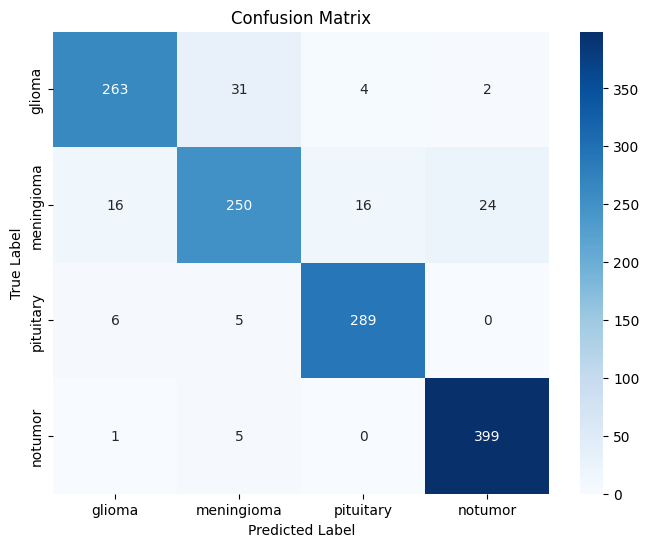


Calculation of ROC curves...


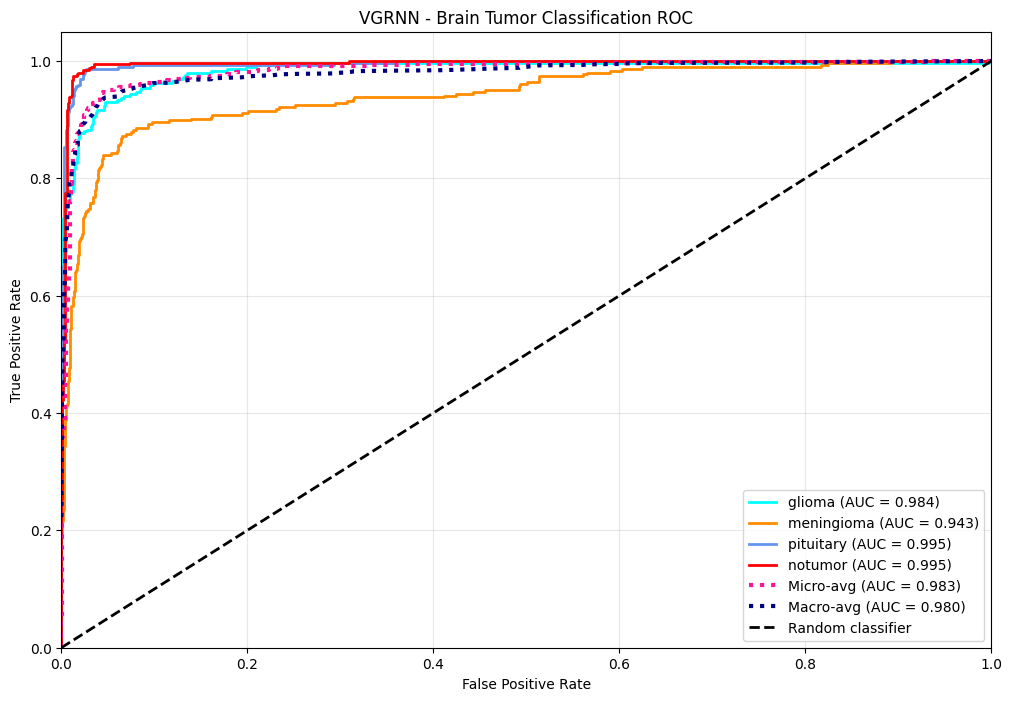

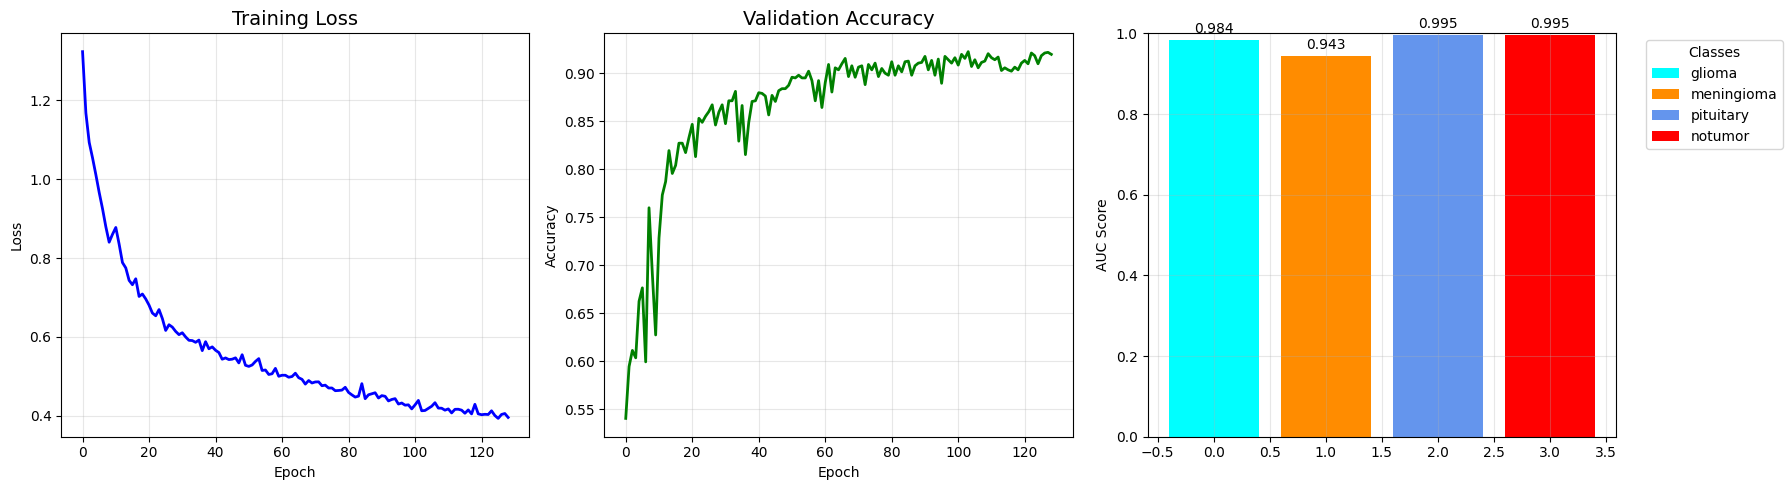

Modèle sauvegardé sous 'vgrnn_brain_tumor_model.pth'


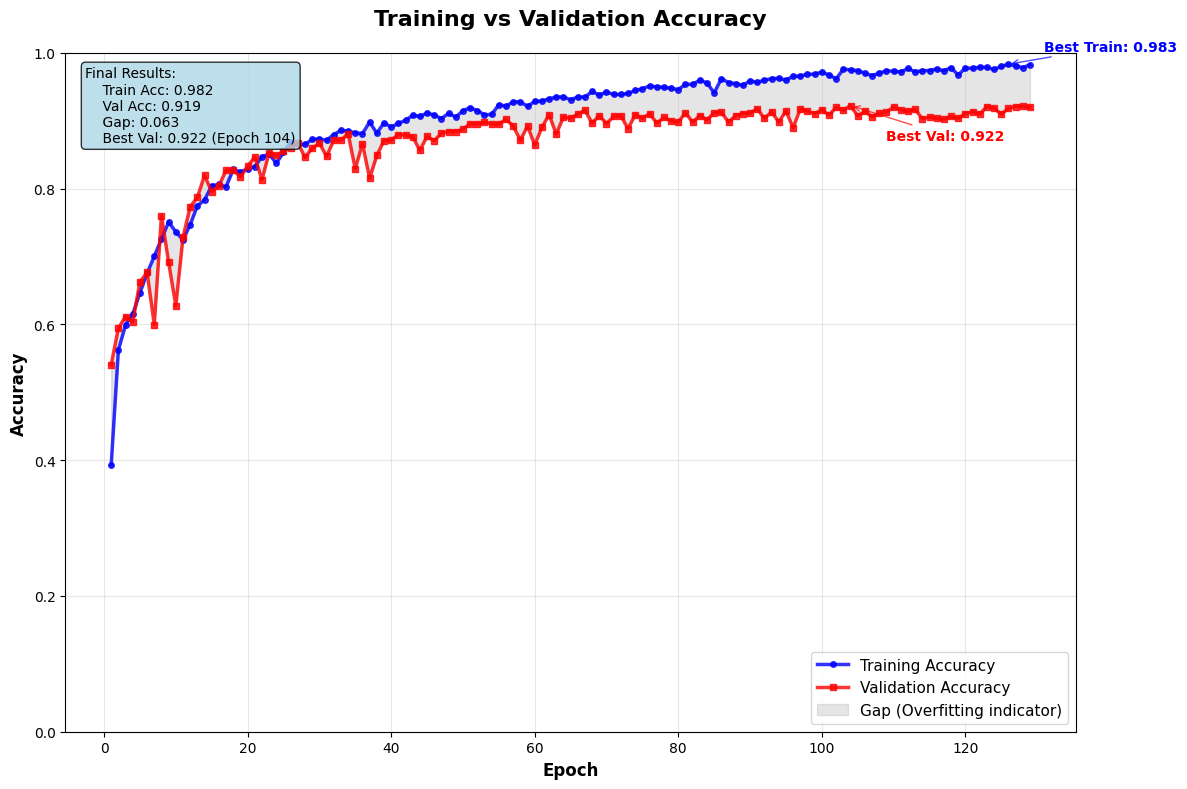

Computing calibration metrics with 50 MC samples...


Processing batches: 100%|██████████| 41/41 [01:39<00:00,  2.43s/it]



Dataset statistics:
  Total samples: 1311
  Number of classes: 4
  Mean epistemic uncertainty: 0.0320
  Mean aleatoric uncertainty: 0.3971

CALIBRATION METRICS (with Variational Inference)
Expected Calibration Error (ECE): 0.0555
Maximum Calibration Error (MCE):  0.2587
Accuracy:                          0.9184
Average Confidence:                0.8907
Brier Score:                       0.1328
Negative Log-Likelihood:           0.8771

Figure saved to: /kaggle/working/reliability_diagram_vgrnn.png


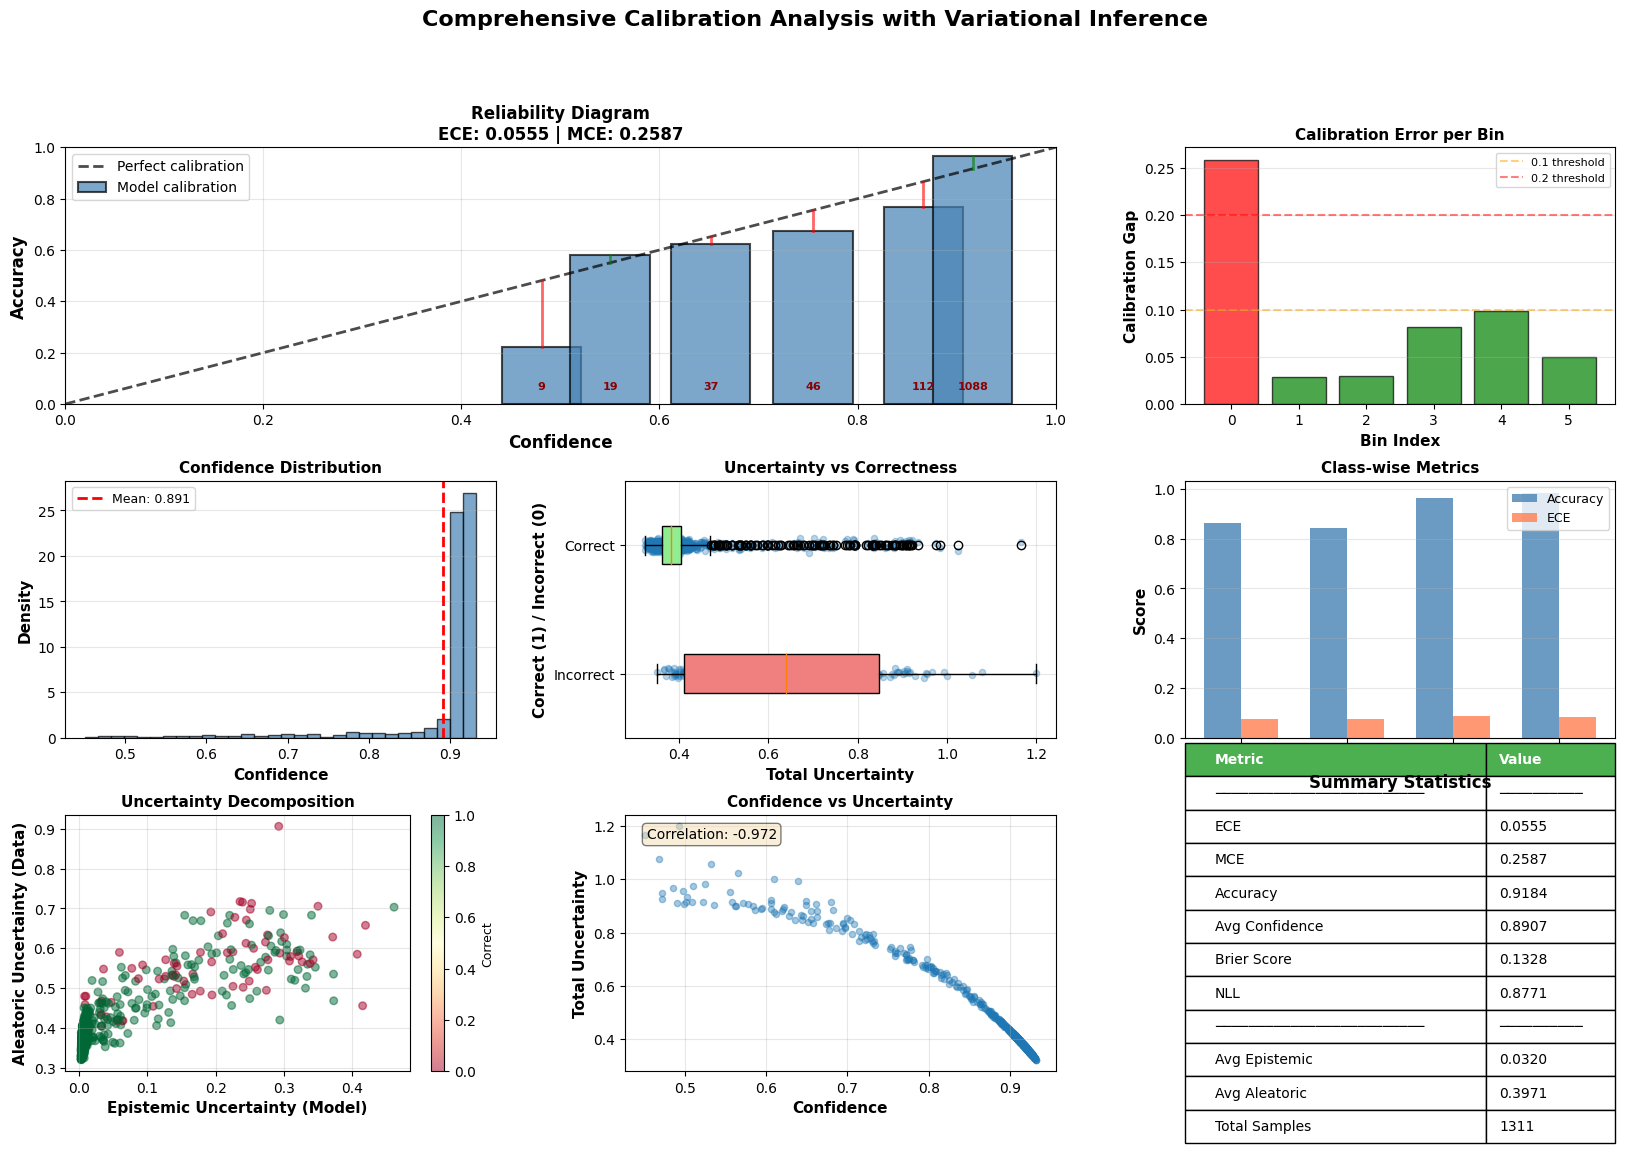

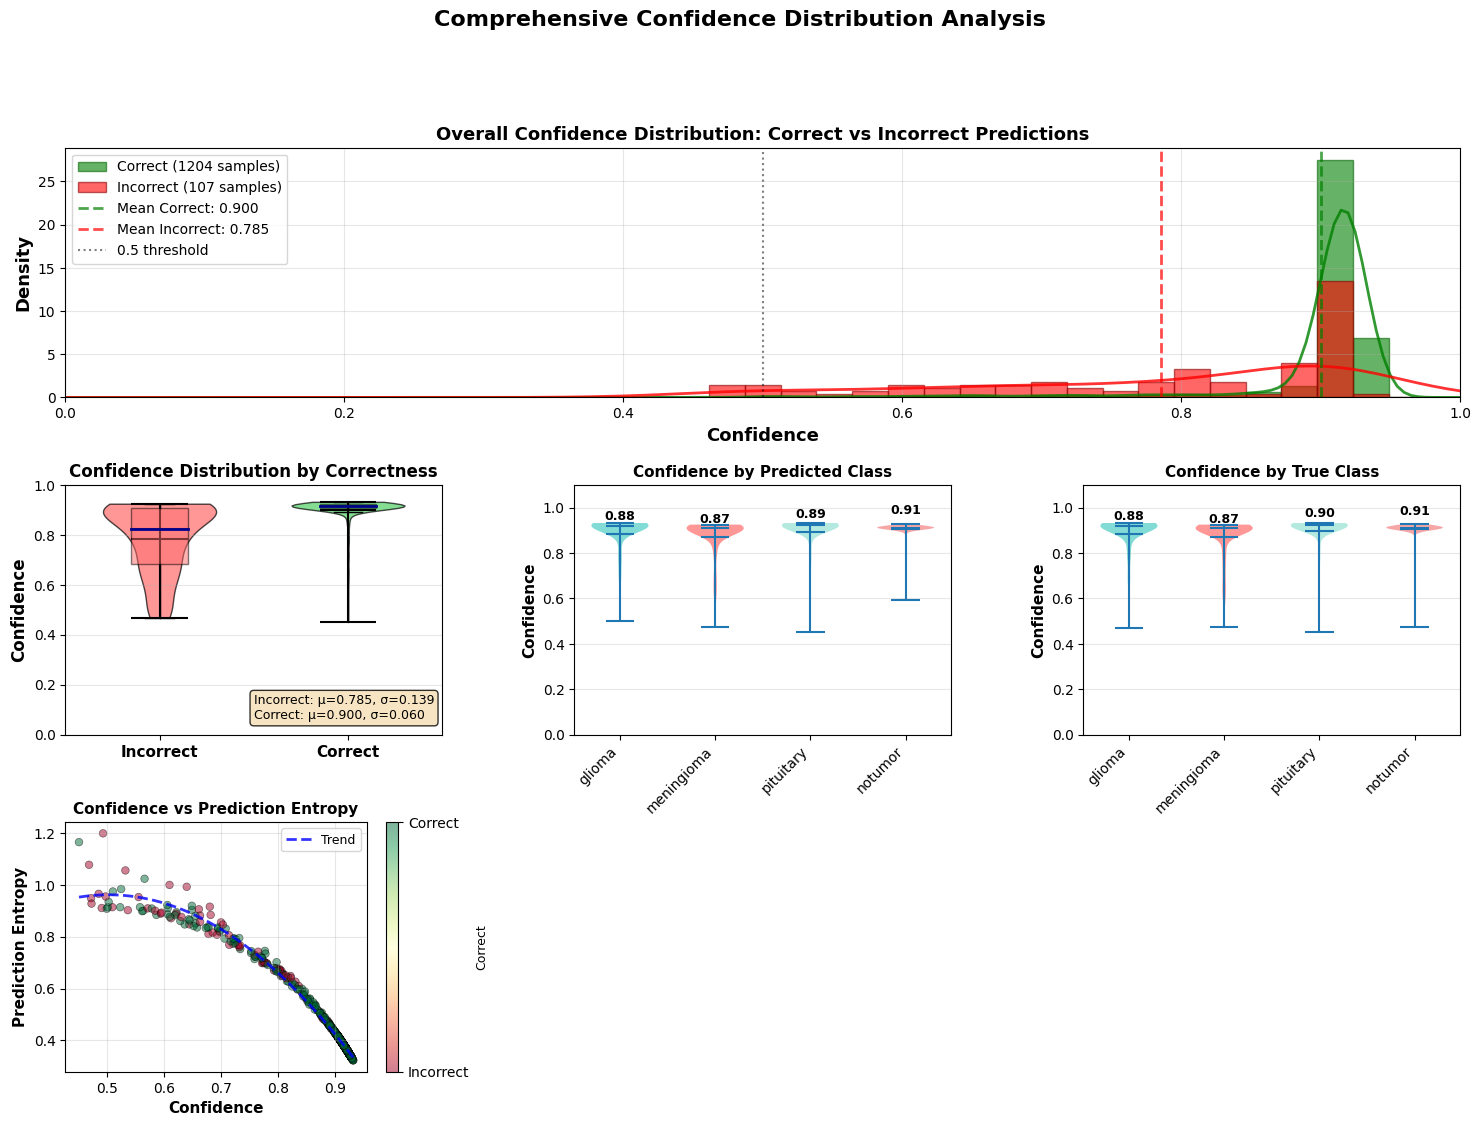

Computing calibration metrics with 50 MC samples...


Processing batches: 100%|██████████| 41/41 [01:39<00:00,  2.43s/it]


Dataset statistics:
  Total samples: 1311
  Number of classes: 4
  Mean epistemic uncertainty: 0.0312
  Mean aleatoric uncertainty: 0.3977

CALIBRATION METRICS (with Variational Inference)
Expected Calibration Error (ECE): 0.0605
Maximum Calibration Error (MCE):  0.1680
Accuracy:                          0.9199
Average Confidence:                0.8906
Brier Score:                       0.1322
Negative Log-Likelihood:           0.8767


In [8]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.loader import DataLoader as GeometricDataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from skimage import segmentation, measure, feature
from scipy.spatial.distance import pdist, squareform
from torch_geometric.explain import Explainer, GNNExplainer
import networkx as nx
from tqdm import tqdm
from itertools import cycle
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')


class ImprovedVGRNNCell(nn.Module):
    """Cellule VGRNN améliorée avec architecture plus robuste"""

    def __init__(self, input_dim, hidden_dim, latent_dim, num_classes, dropout_rate=0.1):
        super(ImprovedVGRNNCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate

        # Architecture d'encodage améliorée avec normalisation
        self.phi_x = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        self.phi_z = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Architecture variationelle améliorée
        self.prior_mean = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim)
        )
        
        self.prior_std = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, latent_dim),
            nn.Softplus(),
            nn.Hardtanh(min_val=0.01, max_val=1.5)
        )

        self.rec_mean = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.3),
            nn.Linear(hidden_dim, latent_dim)
        )
        
        self.rec_std = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Softplus(),
            nn.Hardtanh(min_val=0.01, max_val=1.5)
        )

        # Architecture GCN multicouche améliorée
        self.gcn_layers = nn.ModuleList([
            GCNConv(input_dim + latent_dim, hidden_dim),
            GCNConv(hidden_dim, hidden_dim),
            GCNConv(hidden_dim, hidden_dim)
        ])
        
        # Normalisation pour chaque couche GCN
        self.gcn_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(3)
        ])
        
        # Connexions résiduelles
        self.residual_projections = nn.ModuleList([
            nn.Linear(input_dim + latent_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Linear(hidden_dim, hidden_dim)
        ])

        # GRU multicouche avec normalisation
        self.gru_layers = nn.ModuleList([
            nn.GRUCell(hidden_dim, hidden_dim),
            nn.GRUCell(hidden_dim, hidden_dim)
        ])
        
        self.gru_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim) for _ in range(2)
        ])

        # Dropout adaptatif
        self.gcn_dropout = nn.Dropout(dropout_rate * 0.3)
        self.gru_dropout = nn.Dropout(dropout_rate * 0.5)
        self.feature_dropout = nn.Dropout(dropout_rate * 0.2)

        # Attention pour pondérer les représentations temporelles
        self.temporal_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.Tanh(),
            nn.Linear(hidden_dim // 4, 1)
        )

    def reparameterize(self, mean, std):
        """Reparameterization trick avec stabilité numérique"""
        if self.training:
            eps = torch.randn_like(std)
            return mean + eps * std
        else:
            return mean

    def forward(self, x, edge_index, h_prev=None):
        num_nodes = x.size(0)
        device = x.device

        # Initialisation des états cachés multicouche
        if h_prev is None:
            h_prev = [torch.zeros(num_nodes, self.hidden_dim, device=device) for _ in range(2)]
        
        # Encodage des features avec dropout adaptatif
        x_encoded = self.feature_dropout(x)
        phi_x_t = self.phi_x(x_encoded)

        # Distribution a priori basée sur l'état précédent
        prior_input = h_prev[-1]  # Utiliser le dernier état
        prior_mean_t = self.prior_mean(prior_input)
        prior_std_t = self.prior_std(prior_input)

        # Distribution de reconnaissance
        rec_input = torch.cat([phi_x_t, h_prev[-1]], dim=-1)
        rec_mean_t = self.rec_mean(rec_input)
        rec_std_t = self.rec_std(rec_input)

        # Échantillonnage variationnel
        z_t = self.reparameterize(rec_mean_t, rec_std_t)

        # Architecture GCN multicouche avec connexions résiduelles
        gnn_input = torch.cat([x, z_t], dim=-1)
        
        for i, (gcn_layer, norm, proj) in enumerate(zip(self.gcn_layers, self.gcn_norms, self.residual_projections)):
            # Connexion résiduelle
            residual = proj(gnn_input if i == 0 else h_gcn)
            
            # Propagation GCN
            h_gcn = gcn_layer(gnn_input if i == 0 else h_gcn, edge_index)
            h_gcn = norm(h_gcn)
            h_gcn = F.relu(h_gcn + residual)  # Connexion résiduelle
            h_gcn = self.gcn_dropout(h_gcn)

        # Architecture GRU multicouche
        h_new = []
        gru_input = h_gcn
        
        for i, (gru_layer, norm) in enumerate(zip(self.gru_layers, self.gru_norms)):
            h_layer = gru_layer(gru_input, h_prev[i])
            h_layer = norm(h_layer)
            h_layer = self.gru_dropout(h_layer)
            h_new.append(h_layer)
            gru_input = h_layer

        return h_new[-1], h_new, (prior_mean_t, prior_std_t), (rec_mean_t, rec_std_t)


class MultiPooling(nn.Module):
    """Module personnalisé pour le pooling multiple"""
    def __init__(self):
        super(MultiPooling, self).__init__()
    
    def forward(self, x, batch):
        # Calcul des trois types de pooling
        mean_pool = global_mean_pool(x, batch)
        max_pool = global_max_pool(x, batch)
        add_pool = global_add_pool(x, batch)
        
        # Concaténation des résultats
        return torch.cat([mean_pool, max_pool, add_pool], dim=-1)


class ImprovedVGRNN(nn.Module):
    """Modèle VGRNN amélioré avec architecture plus sophistiquée"""

    def __init__(self, input_dim, hidden_dim, latent_dim, num_classes, num_timesteps=8, dropout_rate=0.2):
        super(ImprovedVGRNN, self).__init__()
        self.num_timesteps = num_timesteps
        self.hidden_dim = hidden_dim
        self.vgrnn_cell = ImprovedVGRNNCell(input_dim, hidden_dim, latent_dim, num_classes, dropout_rate)
        self.dropout_rate = dropout_rate

        # Module de pooling multiple
        self.multi_pooling = MultiPooling()

        # Transformation des représentations poolées
        self.pool_transform = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Attention temporelle pour pondérer les différents pas de temps
        self.temporal_attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

        # Classificateur final plus robuste
        self.final_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.7),
            
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.LayerNorm(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),
            
            nn.Linear(hidden_dim // 4, num_classes)
        )

        # Normalisation finale
        self.final_norm = nn.LayerNorm(hidden_dim)

    def forward(self, data):
        device = data.x.device
        num_nodes = data.x.size(0)
        
        # Initialisation des états cachés
        h = None
        
        # Stockage des représentations temporelles
        temporal_representations = []
        kld_losses = []

        # Évolution temporelle avec perturbations contrôlées
        base_features = data.x
        
        for t in range(self.num_timesteps):
            # Stratégie de perturbation améliorée
            if t == 0:
                x_t = base_features
            else:
                # Perturbation adaptative basée sur la variance des features
                feature_std = torch.std(base_features, dim=0, keepdim=True)
                noise_scale = 0.01 * (1 + t * 0.02)  # Augmentation progressive
                noise = torch.randn_like(base_features) * feature_std * noise_scale
                x_t = base_features + noise

            # Forward pass dans la cellule VGRNN
            node_output, h, (prior_mean, prior_std), (rec_mean, rec_std) = \
                self.vgrnn_cell(x_t, data.edge_index, h)

            temporal_representations.append(node_output)

            # Calcul de la divergence KL avec pondération temporelle
            kld = self.kl_divergence(rec_mean, rec_std, prior_mean, prior_std)
            # Pondération temporelle : plus de poids aux derniers pas de temps
            temporal_weight = (t + 1) / self.num_timesteps
            kld_losses.append(kld * temporal_weight)

        # Attention temporelle pour combiner les représentations
        stacked_representations = torch.stack(temporal_representations, dim=1)  # [num_nodes, num_timesteps, hidden_dim]
        
        # Calcul des scores d'attention
        attention_scores = []
        for t in range(self.num_timesteps):
            score = self.temporal_attention(stacked_representations[:, t, :])
            attention_scores.append(score)
        
        attention_weights = F.softmax(torch.cat(attention_scores, dim=1), dim=1)
        
        # Combinaison pondérée des représentations temporelles
        weighted_representation = torch.sum(
            stacked_representations * attention_weights.unsqueeze(-1), dim=1
        )

        # Pooling multiple et fusion
        if hasattr(data, 'batch'):
            # Utilisation du module de pooling multiple
            multi_pooled = self.multi_pooling(weighted_representation, data.batch)
            graph_representation = self.pool_transform(multi_pooled)
        else:
            # Pour un seul graphe
            graph_representation = weighted_representation.mean(dim=0, keepdim=True)

        # Normalisation finale
        graph_representation = self.final_norm(graph_representation)

        # Classification finale
        final_outputs = self.final_classifier(graph_representation)
        total_kld = sum(kld_losses)

        return final_outputs, total_kld

    def kl_divergence(self, rec_mean, rec_std, prior_mean, prior_std):
        """Calcul optimisé de la divergence KL avec stabilité numérique"""
        # Clipping pour la stabilité
        rec_std = torch.clamp(rec_std, min=1e-6, max=10.0)
        prior_std = torch.clamp(prior_std, min=1e-6, max=10.0)

        # KL divergence avec stabilité numérique améliorée
        kld = torch.log(prior_std + 1e-8) - torch.log(rec_std + 1e-8) + \
              (rec_std.pow(2) + (rec_mean - prior_mean).pow(2)) / (2 * prior_std.pow(2) + 1e-8) - 0.5

        # Clipping final et moyenne
        kld = torch.clamp(kld, min=-5, max=5)
        return kld.mean()


def train_model_improved(model, train_loader, val_loader, num_epochs=100, learning_rate=0.001, 
                        patience=15, min_delta=0.001, warmup_epochs=10):
    """Entraînement amélioré avec warmup et scheduling adaptatif"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    # Optimiseur avec paramètres différentiés
    gcn_params = []
    gru_params = []
    other_params = []
    
    for name, param in model.named_parameters():
        if 'gcn' in name.lower():
            gcn_params.append(param)
        elif 'gru' in name.lower():
            gru_params.append(param)
        else:
            other_params.append(param)

    # Optimiseur avec learning rates différenciés
    optimizer = torch.optim.AdamW([
        {'params': gcn_params, 'lr': learning_rate, 'weight_decay': 1e-5},
        {'params': gru_params, 'lr': learning_rate * 0.8, 'weight_decay': 1e-4},
        {'params': other_params, 'lr': learning_rate * 1.2, 'weight_decay': 1e-5}
    ], betas=(0.9, 0.999), eps=1e-8)

    # Scheduler avec warmup
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            return 0.95 ** ((epoch - warmup_epochs) // 10)

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # Critère avec pondération des classes si nécessaire
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Métriques de suivi
    train_losses = []
    val_accuracies = []
    train_accuracies = []


    best_val_accuracy = -float('inf')
    best_model_state = None
    epochs_no_improve = 0
    early_stop_epoch = None

    print(f"Training with {sum(p.numel() for p in model.parameters())} parameters")
    print(f"Device: {device}")

    for epoch in range(num_epochs):
        # Phase d'entraînement
        model.train()
        total_loss = 0
        total_reconstruction_loss = 0
        total_kld_loss = 0
        train_predictions = []
        train_targets = []

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        
        for batch_idx, batch in enumerate(progress_bar):
            batch = batch.to(device)
            optimizer.zero_grad()

            # Forward pass
            outputs, kld_loss = model(batch)
            
            # Perte de classification
            reconstruction_loss = criterion(outputs, batch.y.squeeze())

            # KL annealing amélioré
            if epoch < warmup_epochs:
                beta = 0.1 * (epoch / warmup_epochs)
            else:
                beta = min(1.0, 0.5 + 0.9 * ((epoch - warmup_epochs) / (num_epochs - warmup_epochs)))

            # Perte totale
            total_loss_batch = reconstruction_loss + beta * kld_loss

            # Vérification de stabilité
            if torch.isnan(total_loss_batch) or torch.isinf(total_loss_batch):
                print(f"Loss instable détectée à l'époque {epoch}, batch {batch_idx}")
                continue

            # Backward pass avec gradient clipping
            total_loss_batch.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # Accumulation des métriques
            total_loss += total_loss_batch.item()
            total_reconstruction_loss += reconstruction_loss.item()
            total_kld_loss += kld_loss.item()

            # Prédictions pour l'accuracy
            predictions = torch.argmax(outputs, dim=1)
            train_predictions.extend(predictions.cpu().numpy())
            train_targets.extend(batch.y.squeeze().cpu().numpy())

            # Mise à jour de la barre de progression
            progress_bar.set_postfix({
                'Loss': f'{total_loss_batch.item():.4f}',
                'Beta': f'{beta:.3f}',
                'LR': f'{optimizer.param_groups[0]["lr"]:.6f}'
            })

        # Calcul de l'accuracy d'entraînement
        train_accuracy = accuracy_score(train_targets, train_predictions)

        # Phase de validation
        model.eval()
        val_predictions = []
        val_targets = []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                outputs, _ = model(batch)
                predictions = torch.argmax(outputs, dim=1)
                val_predictions.extend(predictions.cpu().numpy())
                val_targets.extend(batch.y.squeeze().cpu().numpy())

        val_accuracy = accuracy_score(val_targets, val_predictions)

        # Moyennes des métriques
        avg_loss = total_loss / len(train_loader)
        avg_rec_loss = total_reconstruction_loss / len(train_loader)
        avg_kld_loss = total_kld_loss / len(train_loader)

        # Sauvegarde des métriques
        train_losses.append(avg_loss)
        val_accuracies.append(val_accuracy)
        train_accuracies.append(train_accuracy)

        # Affichage des résultats
        print(f'\nEpoch {epoch+1}/{num_epochs}:')
        print(f'  Train Loss: {avg_loss:.4f} (Rec: {avg_rec_loss:.4f}, KLD: {avg_kld_loss:.4f})')
        print(f'  Train Accuracy: {train_accuracy:.4f}')
        print(f'  Val Accuracy: {val_accuracy:.4f}')
        print(f'  Beta (KL weight): {beta:.4f}')
        print(f'  Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')

        # Early stopping
        if val_accuracy > best_val_accuracy + min_delta:
            best_val_accuracy = val_accuracy
            best_model_state = model.state_dict()
            epochs_no_improve = 0
            print(f"  ✓ New improved accuracy: {best_val_accuracy:.4f}")
        else:
            epochs_no_improve += 1
            print(f"  → No improvement ({epochs_no_improve}/{patience})")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping après {epoch+1} époques")
            early_stop_epoch = epoch + 1
            break

        # Mise à jour du learning rate
        scheduler.step()

        # Arrêt en cas d'instabilité
        if avg_kld_loss > 50:
            print("KL divergence trop élevée, arrêt anticipé")
            break

    # Restauration du meilleur modèle
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n Best restored model (Val Accuracy: {best_val_accuracy:.4f})")

    return train_losses, train_accuracies, val_accuracies, early_stop_epoch

def plot_train_val_accuracy(train_accuracies, val_accuracies, early_stop_epoch=None, 
                           save_path=None, title="Training vs Validation Accuracy"):
    """
    Displays training and validation accuracy curves

    """
    
    plt.figure(figsize=(12, 8))
    epochs = range(1, len(train_accuracies) + 1)
    
    # Courbes principales
    plt.plot(epochs, train_accuracies, 'b-', linewidth=2.5, marker='o', 
             markersize=4, label='Training Accuracy', alpha=0.8)
    plt.plot(epochs, val_accuracies, 'r-', linewidth=2.5, marker='s', 
             markersize=4, label='Validation Accuracy', alpha=0.8)
    
    # Zone entre les courbes pour visualiser l'écart
    plt.fill_between(epochs, train_accuracies, val_accuracies, 
                     alpha=0.2, color='gray', label='Gap (Overfitting indicator)')
    
    # Ligne d'early stopping
    if early_stop_epoch is not None:
        plt.axvline(x=early_stop_epoch, color='green', linestyle='--', 
                   linewidth=2, alpha=0.7, label=f'Early Stop (Epoch {early_stop_epoch})')
    
    # Statistiques
    max_train_acc = max(train_accuracies)
    max_train_epoch = train_accuracies.index(max_train_acc) + 1
    max_val_acc = max(val_accuracies)
    max_val_epoch = val_accuracies.index(max_val_acc) + 1
    
    final_train_acc = train_accuracies[-1]
    final_val_acc = val_accuracies[-1]
    final_gap = abs(final_train_acc - final_val_acc)
    
    # Annotations
    plt.annotate(f'Best Train: {max_train_acc:.3f}', 
                xy=(max_train_epoch, max_train_acc), 
                xytext=(max_train_epoch + 5, max_train_acc + 0.02),
                arrowprops=dict(arrowstyle='->', color='blue', alpha=0.7),
                fontsize=10, color='blue', fontweight='bold')
    
    plt.annotate(f'Best Val: {max_val_acc:.3f}', 
                xy=(max_val_epoch, max_val_acc), 
                xytext=(max_val_epoch + 5, max_val_acc - 0.05),
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7),
                fontsize=10, color='red', fontweight='bold')
    
    # Boîte d'informations
    info_text = f"""Final Results:
    Train Acc: {final_train_acc:.3f}
    Val Acc: {final_val_acc:.3f}
    Gap: {final_gap:.3f}
    Best Val: {max_val_acc:.3f} (Epoch {max_val_epoch})"""
    
    plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', 
             facecolor='lightblue', alpha=0.8), fontsize=10)
    
    # Configuration du graphique
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11, loc='lower right')
    plt.ylim([0, 1])
    
    # Améliorer l'apparence
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Graphique sauvegardé: {save_path}")
    
    plt.show()

def plot_roc_multiclass(y_true, y_pred_proba, class_names, title="Multi-class ROC Curves"):
    """Displays ROC curves for multi-class classification"""
    n_classes = len(class_names)

    # Binarisation des labels
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # Si seulement 2 classes, label_binarize retourne un array 1D
    if n_classes == 2:
        y_true_bin = np.column_stack([1 - y_true_bin, y_true_bin])

    # Calcul ROC pour chaque classe
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # ROC micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # ROC macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Graphique
    plt.figure(figsize=(12, 8))

    # Couleurs pour chaque classe
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red', 'green', 'purple'])

    # ROC pour chaque classe
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

    # ROC micro et macro-average
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-avg (AUC = {roc_auc["micro"]:.3f})',
             color='deeppink', linestyle=':', linewidth=3)

    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-avg (AUC = {roc_auc["macro"]:.3f})',
             color='navy', linestyle=':', linewidth=3)

    # Ligne de référence
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

    return roc_auc

def evaluate_model(model, test_loader, class_names):
    """Model evaluation"""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    all_predictions = []
    all_targets = []
    all_probabilities = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Évaluation'):
            batch = batch.to(device)
            outputs, _ = model(batch)

            # Probabilités avec softmax
            probabilities = F.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            # Stocker les résultats
            all_probabilities.append(probabilities.cpu().numpy())
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(batch.y.cpu().numpy())

    # Concaténer tous les résultats
    all_probabilities = np.vstack(all_probabilities)
    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)

    # Calculer les métriques
    accuracy = accuracy_score(all_targets, all_predictions)
    report = classification_report(all_targets, all_predictions,
                                 target_names=class_names, output_dict=True)

    print(f'Accuracy de test: {accuracy:.4f}')
    print('\nClassification report:')
    print(classification_report(all_targets, all_predictions, target_names=class_names))

    # Matrice de confusion
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(all_targets, all_predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Courbes ROC
    print("\nCalculation of ROC curves...")
    roc_auc_scores = plot_roc_multiclass(all_targets, all_probabilities,
                                       class_names, "VGRNN - Brain Tumor Classification ROC")

    return accuracy, report, all_predictions, all_targets, roc_auc_scores

def plot_training_history_with_roc(train_losses, val_accuracies, roc_scores=None):
    """Displays training history, including ROC scores if available."""
    if roc_scores is not None:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Loss d'entraînement
    axes[0].plot(train_losses, 'b-', linewidth=2)
    axes[0].set_title('Training Loss', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)

    # Accuracy de validation
    axes[1].plot(val_accuracies, 'g-', linewidth=2)
    axes[1].set_title('Validation Accuracy', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True, alpha=0.3)

    # Scores ROC si disponibles
    if roc_scores is not None:
        color_map = {
            0: 'glioma',
            1: 'meningioma',
            2: 'pituitary',
            3: 'notumor'
        }
        class_names = list(roc_scores.keys())
        
        class_names = [cls for cls in color_map.keys() if cls in roc_scores]
        auc_values = [roc_scores[cls] for cls in class_names]
        colors = [color_map[cls] for cls in class_names]

        bars = axes[2].bar(class_names, auc_values, color=['aqua', 'darkorange', 'cornflowerblue', 'red'])
        #axes[2].axhline(y=roc_scores['macro'], color='navy', linestyle='--',
         #              label=f'Macro-avg: {roc_scores["macro"]:.3f}')
        #axes[2].set_title('AUC Scores per Class', fontsize=14)
        axes[2].set_ylabel('AUC Score')
        axes[2].set_ylim([0, 1])
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

         # Légende avec association couleur-classe
        for cls, tumor in color_map.items():
            axes[2].bar(0, 0, color=['aqua', 'darkorange', 'cornflowerblue', 'red'][cls], label=tumor)  # bar "invisible" pour la légende
        axes[2].legend(
            title="Classes",
            loc="upper left",
            bbox_to_anchor=(1.05, 1)  # (x, y)
        )

        # Ajouter les valeurs sur les barres
        for bar, value in zip(bars, auc_values):
            axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{value:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


def main_improved():
    BATCH_SIZE = 32  
    HIDDEN_DIM = 128  
    LATENT_DIM = 64   
    NUM_CLASSES = 4
    NUM_EPOCHS = 150
    LEARNING_RATE = 0.0003  
    PATIENCE = 25
    MIN_DELTA = 0.001
    NUM_TIMESTEPS = 10  

    print(f"- Batch Size: {BATCH_SIZE}")
    print(f"- Hidden Dim: {HIDDEN_DIM}")
    print(f"- Latent Dim: {LATENT_DIM}")
    print(f"- Timesteps: {NUM_TIMESTEPS}")
    print(f"- Learning Rate: {LEARNING_RATE}")

    # Note: You need to replace these with your actual datasets
    # This is just a placeholder to show the structure
    
    train_indices, val_indices = train_test_split(
        range(len(graph_dataset_train)),
        test_size=0.25,  # 25% for validation, 75% for training
        random_state=42,
        stratify=[graph_dataset_train[i].y.item() for i in range(len(graph_dataset_train))]
    )

    # Create subsets
    train_dataset = torch.utils.data.Subset(graph_dataset_train, train_indices)
    val_dataset = torch.utils.data.Subset(graph_dataset_train, val_indices)
    test_dataset = graph_dataset_test

    # Create data loaders with GeometricDataLoader
    train_loader = GeometricDataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = GeometricDataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = GeometricDataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

    # Obtain the size of features
    sample_batch = next(iter(train_loader))
    input_dim = sample_batch.x.size(1)
    print(f"Dimension des features: {input_dim}")

    # Creation of the improved model
    model = ImprovedVGRNN(input_dim, HIDDEN_DIM, LATENT_DIM, NUM_CLASSES, 
                          num_timesteps=NUM_TIMESTEPS, dropout_rate=0.15)


    # Training with the new function
    train_losses, train_accuracies, val_accuracies, early_stop_epoch = train_model_improved(
         model, train_loader, val_loader, NUM_EPOCHS, LEARNING_RATE, PATIENCE, MIN_DELTA
    )

    # Évaluation
    print("Évaluation sur le test set...")
    test_accuracy, report, predictions, targets, roc_auc_scores = evaluate_model(
        model, test_loader, ['glioma', 'meningioma', 'pituitary', 'notumor']
    )
    # Results graphs with ROC
    plot_training_history_with_roc(train_losses, val_accuracies, roc_auc_scores)

    # Save the template
    torch.save(model.state_dict(), '/kaggle/working/vgrnn_brain_tumor_model.pth')
    print("Modèle sauvegardé sous 'vgrnn_brain_tumor_model.pth'")

    plot_train_val_accuracy(train_accuracies, val_accuracies, early_stop_epoch=None, 
                           save_path=None, title="Training vs Validation Accuracy")

    # Visualisation
    #results = visualize_vgrnn_latent_space(
    #    model, 
    #    val_loader,  # ou test_loader
    #    save_dir='/kaggle/working'
    #)
    

    return  model, test_loader, test_dataset

class VGRNNWrapper(nn.Module):
    """Wrapper to make ImprovedVGRNN compatible with GNNExplainer"""
    
    def __init__(self, vgrnn_model):
        super().__init__()
        self.vgrnn_model = vgrnn_model
    
    def forward(self, x, edge_index, batch=None, **kwargs):
        """
        Convert GNNExplainer's (x, edge_index, batch) format to VGRNN's data format
        """
        # Create a Data-like object that VGRNN expects
        from torch_geometric.data import Data
        
        data = Data(x=x, edge_index=edge_index)
        
        # Add batch tensor if provided (for graph-level pooling)
        if batch is not None:
            data.batch = batch
        else:
            # Default: all nodes in one graph
            data.batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        
        # Forward pass and extract only the prediction (discard KLD)
        predictions, _ = self.vgrnn_model(data)
        return predictions

if __name__ == "__main__":
    model, test_loader, test_dataset = main_improved()
    ece, brier, acc = compute_ece_and_reliability_diagram(
        model=model,
        test_loader=test_loader,
        num_bins=10,  # ou 10, 20... 15 est souvent un bon compromis
        save_path="/kaggle/working/reliability_diagram_vgrnn.png"  # optionnel
    )
    compute_ece_mce_vgrnn(model, test_loader)
    
